# 📱 Cell2Cell Telecom Churn Prediction
## World-Class End-to-End Machine Learning Pipeline

---

**Dataset:** Cell2Cell Telecom — 51,047 customers, 57 features  
**Target:** Binary classification — `Churn` (Yes/No)  
**Goal:** Build the most accurate and interpretable churn prediction system

### Pipeline Overview
1. 📊 Exploratory Data Analysis (EDA)
2. 🛠️ Feature Engineering
3. ⚙️ Preprocessing Pipeline
4. 🤖 Multi-Model Training (LR, RF, XGBoost, LightGBM, CatBoost)
5. 🔧 Hyperparameter Tuning (Optuna)
6. 📈 Model Evaluation & Comparison
7. 🔍 Feature Importance & Interpretability
8. 💼 Business Insights & Recommendations
9. 🏆 Final Ensemble Model


In [1]:
# ============================================================
# CELL 1: INSTALL & IMPORT
# ============================================================
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.figure_factory as ff

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler, RobustScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    roc_auc_score, accuracy_score, f1_score, precision_score, recall_score,
    confusion_matrix, classification_report, roc_curve, precision_recall_curve,
    average_precision_score
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (
    RandomForestClassifier, GradientBoostingClassifier,
    VotingClassifier, StackingClassifier
)
from sklearn.inspection import permutation_importance
from sklearn.calibration import CalibratedClassifierCV, calibration_curve

import xgboost as xgb
import lightgbm as lgb
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

import json, os, pickle
from IPython.display import display, HTML

# Styling
sns.set_theme(style='whitegrid', palette='husl')
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})
PALETTE = ['#2ecc71', '#e74c3c']
SEED = 42
np.random.seed(SEED)

print('✅ All imports successful!')
print(f'  XGBoost: {xgb.__version__}')
print(f'  LightGBM: {lgb.__version__}')
print(f'  Optuna: {optuna.__version__}')

✅ All imports successful!
  XGBoost: 3.2.0
  LightGBM: 4.6.0
  Optuna: 4.7.0


## 1. 📊 Data Loading & Overview

In [2]:
# ============================================================
# CELL 2: LOAD DATA
# ============================================================
df = pd.read_csv('cell2celltrain.csv')

print('═'*60)
print('       CELL2CELL CHURN DATASET — OVERVIEW')
print('═'*60)
print(f'  Rows    : {df.shape[0]:,}')
print(f'  Columns : {df.shape[1]}')
print(f'  Memory  : {df.memory_usage(deep=True).sum() / 1e6:.1f} MB')
churn_rate = (df['Churn']=='Yes').mean()
print(f'  Churn Rate: {churn_rate:.1%}  ({(df["Churn"]=="Yes").sum():,} churned)')
print('═'*60)
display(df.head(3))

════════════════════════════════════════════════════════════
       CELL2CELL CHURN DATASET — OVERVIEW
════════════════════════════════════════════════════════════
  Rows    : 51,047
  Columns : 58
  Memory  : 75.8 MB
  Churn Rate: 28.8%  (14,711 churned)
════════════════════════════════════════════════════════════


,CustomerID,Churn,MonthlyRevenue,MonthlyMinutes,TotalRecurringCharge,DirectorAssistedCalls,OverageMinutes,RoamingCalls,PercChangeMinutes,PercChangeRevenues,...,ReferralsMadeBySubscriber,IncomeGroup,OwnsMotorcycle,AdjustmentsToCreditRating,HandsetPrice,MadeCallToRetentionTeam,CreditRating,PrizmCode,Occupation,MaritalStatus
0,3000002,Yes,24.00,219.0,22.0,0.25,0.0,0.0,-157.0,-19.0,...,0,4,No,0,30,Yes,1-Highest,Suburban,Professional,No
1,3000010,Yes,16.99,10.0,17.0,0.00,0.0,0.0,-4.0,0.0,...,0,5,No,0,30,No,4-Medium,Suburban,Professional,Yes
2,3000014,No,38.00,8.0,38.0,0.00,0.0,0.0,-2.0,0.0,...,0,6,No,0,Unknown,No,3-Good,Town,Crafts,Yes


In [3]:
# ============================================================
# CELL 3: DATA QUALITY REPORT
# ============================================================
def data_quality_report(df):
    report = pd.DataFrame({
        'dtype': df.dtypes,
        'missing': df.isnull().sum(),
        'missing_%': (df.isnull().sum() / len(df) * 100).round(2),
        'unique': df.nunique(),
        'cardinality_%': (df.nunique() / len(df) * 100).round(3)
    })
    report = report[report['missing'] > 0].sort_values('missing_%', ascending=False)
    return report

print('🔍 Missing Values Report:')
display(data_quality_report(df))

print('\n📊 Categorical Columns:')
cat_cols = df.select_dtypes('object').columns.tolist()
cat_cols.remove('CustomerID') if 'CustomerID' in cat_cols else None
for col in cat_cols:
    if col != 'Churn':
        print(f'  {col:30s}: {df[col].unique()}')

🔍 Missing Values Report:


,dtype,missing,missing_%,unique,cardinality_%
AgeHH2,float64,909,1.78,43,0.084
AgeHH1,float64,909,1.78,43,0.084
PercChangeRevenues,float64,367,0.72,2899,5.679
PercChangeMinutes,float64,367,0.72,2262,4.431
MonthlyRevenue,float64,156,0.31,12665,24.810
MonthlyMinutes,float64,156,0.31,2719,5.326
RoamingCalls,float64,156,0.31,530,1.038
OverageMinutes,float64,156,0.31,746,1.461
DirectorAssistedCalls,float64,156,0.31,146,0.286
TotalRecurringCharge,float64,156,0.31,214,0.419



📊 Categorical Columns:
  ServiceArea                   : ['SEAPOR503' 'PITHOM412' 'MILMIL414' 'OKCTUL918' 'OKCOKC405' 'SANMCA210'
 'SLCSLC801' 'LOULOU502' 'KCYKCK913' 'KCYNEW316' 'KCYKCM816' 'DENDEN303'
 'PHICTR610' 'OKCLRK501' 'OMADES515' 'SANAUS512' 'KCYWIC316' 'INDIND317'
 'SLCPRO801' 'OMALNC402' 'NSHNSH615' 'OMAOMA402' 'PHXTUC520' 'DALDAL214'
 'DALDTN940' 'DALFTW817' 'SANSAN210' 'NYCMAN917' 'NOLKEN504' 'MINMIN612'
 'NNYROC716' 'PHIARD610' 'NYCQUE917' 'DENBOU303' 'BOSBOS617' 'PHXPHX602'
 'NNYBUF716' 'DETTOL419' 'NNYSYR315' 'STLSTL314' 'PHIPHI215' 'SEABLV425'
 'MIAMIA305' 'PHICHC215' 'SEASEA206' 'BIRBIR205' 'MIADFD954' 'LOUNAL812'
 'MIADEL561' 'MIAFTL954' 'SEASPO509' 'SEATAC253' 'SFRSAC916' 'MIANDA305'
 'MINSTP612' 'MIAHWD954' 'NYCBRO917' 'PHIJEN215' 'OMACDR319' 'MIAWPB561'
 'SEAOLY360' 'PITBUT412' 'SEAEVE425' 'PHIMER609' 'SEACDA208' 'HARHAR860'
 'SFRSFR415' 'SFROAK510' 'SFRSCL408' 'NNYALB518' 'STLCOL618' 'NYCNEW201'
 'SFRPAL650' 'DETDET313' 'DETROS810' 'NYCNEW908' 'NYCNAS516' 'NSHC

  ChildrenInHH                  : ['No' 'Yes']
  HandsetRefurbished            : ['No' 'Yes']
  HandsetWebCapable             : ['Yes' 'No']
  TruckOwner                    : ['No' 'Yes']
  RVOwner                       : ['No' 'Yes']
  Homeownership                 : ['Known' 'Unknown']
  BuysViaMailOrder              : ['Yes' 'No']
  RespondsToMailOffers          : ['Yes' 'No']
  OptOutMailings                : ['No' 'Yes']
  NonUSTravel                   : ['No' 'Yes']
  OwnsComputer                  : ['Yes' 'No']
  HasCreditCard                 : ['Yes' 'No']
  NewCellphoneUser              : ['No' 'Yes']
  NotNewCellphoneUser           : ['No' 'Yes']
  OwnsMotorcycle                : ['No' 'Yes']
  HandsetPrice                  : ['30' 'Unknown' '10' '80' '150' '300' '40' '200' '100' '130' '60' '400'
 '240' '250' '180' '500']
  MadeCallToRetentionTeam       : ['Yes' 'No']
  CreditRating                  : ['1-Highest' '4-Medium' '3-Good' '6-VeryLow' '2-High' '5-Low' '7-Lowest']
 

## 2. 📈 Exploratory Data Analysis

In [4]:
# ============================================================
# CELL 4: CHURN DISTRIBUTION
# ============================================================
churn_counts = df['Churn'].value_counts()

fig = make_subplots(rows=1, cols=2,
                    subplot_titles=('Churn Distribution', 'Churn Rate'),
                    specs=[[{'type': 'pie'}, {'type': 'bar'}]])

fig.add_trace(go.Pie(
    labels=churn_counts.index,
    values=churn_counts.values,
    hole=0.5,
    marker_colors=['#2ecc71', '#e74c3c'],
    textinfo='label+percent+value'
), row=1, col=1)

fig.add_trace(go.Bar(
    x=churn_counts.index,
    y=churn_counts.values,
    marker_color=['#2ecc71', '#e74c3c'],
    text=churn_counts.values,
    textposition='auto'
), row=1, col=2)

fig.update_layout(
    title='<b>Customer Churn Overview</b>',
    height=400, showlegend=False,
    template='plotly_white'
)
fig.show()
print(f'  Class Imbalance Ratio — No:Yes = {churn_counts["No"]/churn_counts["Yes"]:.2f}:1')

  Class Imbalance Ratio — No:Yes = 2.47:1


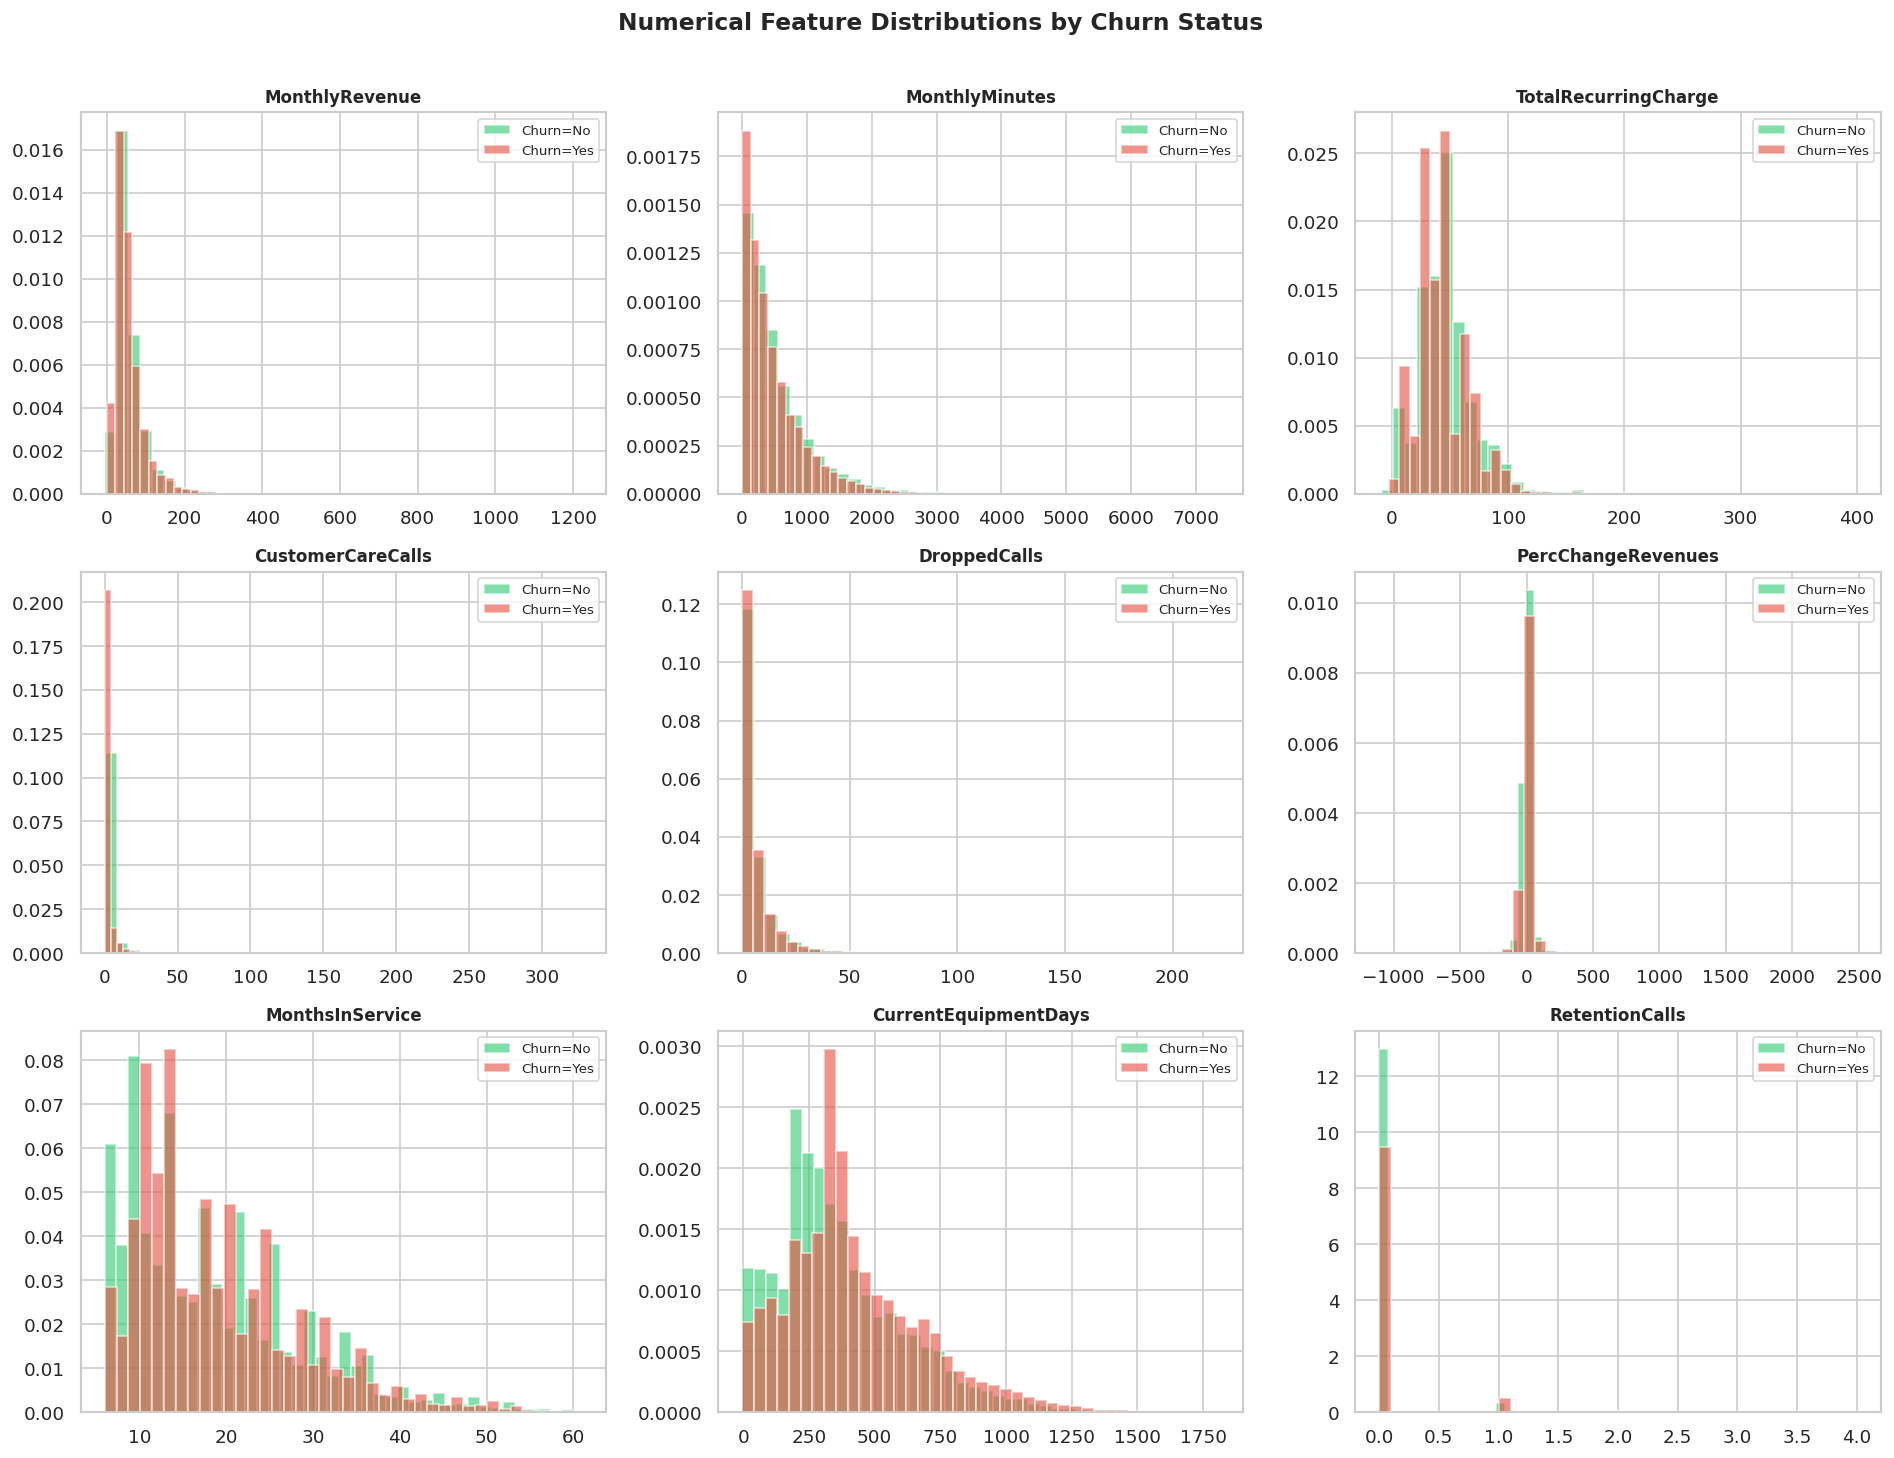

In [5]:
# ============================================================
# CELL 5: NUMERICAL FEATURE DISTRIBUTIONS BY CHURN
# ============================================================
num_cols = [
    'MonthlyRevenue', 'MonthlyMinutes', 'TotalRecurringCharge',
    'CustomerCareCalls', 'DroppedCalls', 'PercChangeRevenues',
    'MonthsInService', 'CurrentEquipmentDays', 'RetentionCalls'
]

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    for label, color in [('No', '#2ecc71'), ('Yes', '#e74c3c')]:
        data = df[df['Churn'] == label][col].dropna()
        axes[i].hist(data, bins=40, alpha=0.6, color=color, label=f'Churn={label}', density=True)
    axes[i].set_title(col, fontweight='bold', fontsize=10)
    axes[i].legend(fontsize=8)
    axes[i].set_xlabel('')

plt.suptitle('Numerical Feature Distributions by Churn Status', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

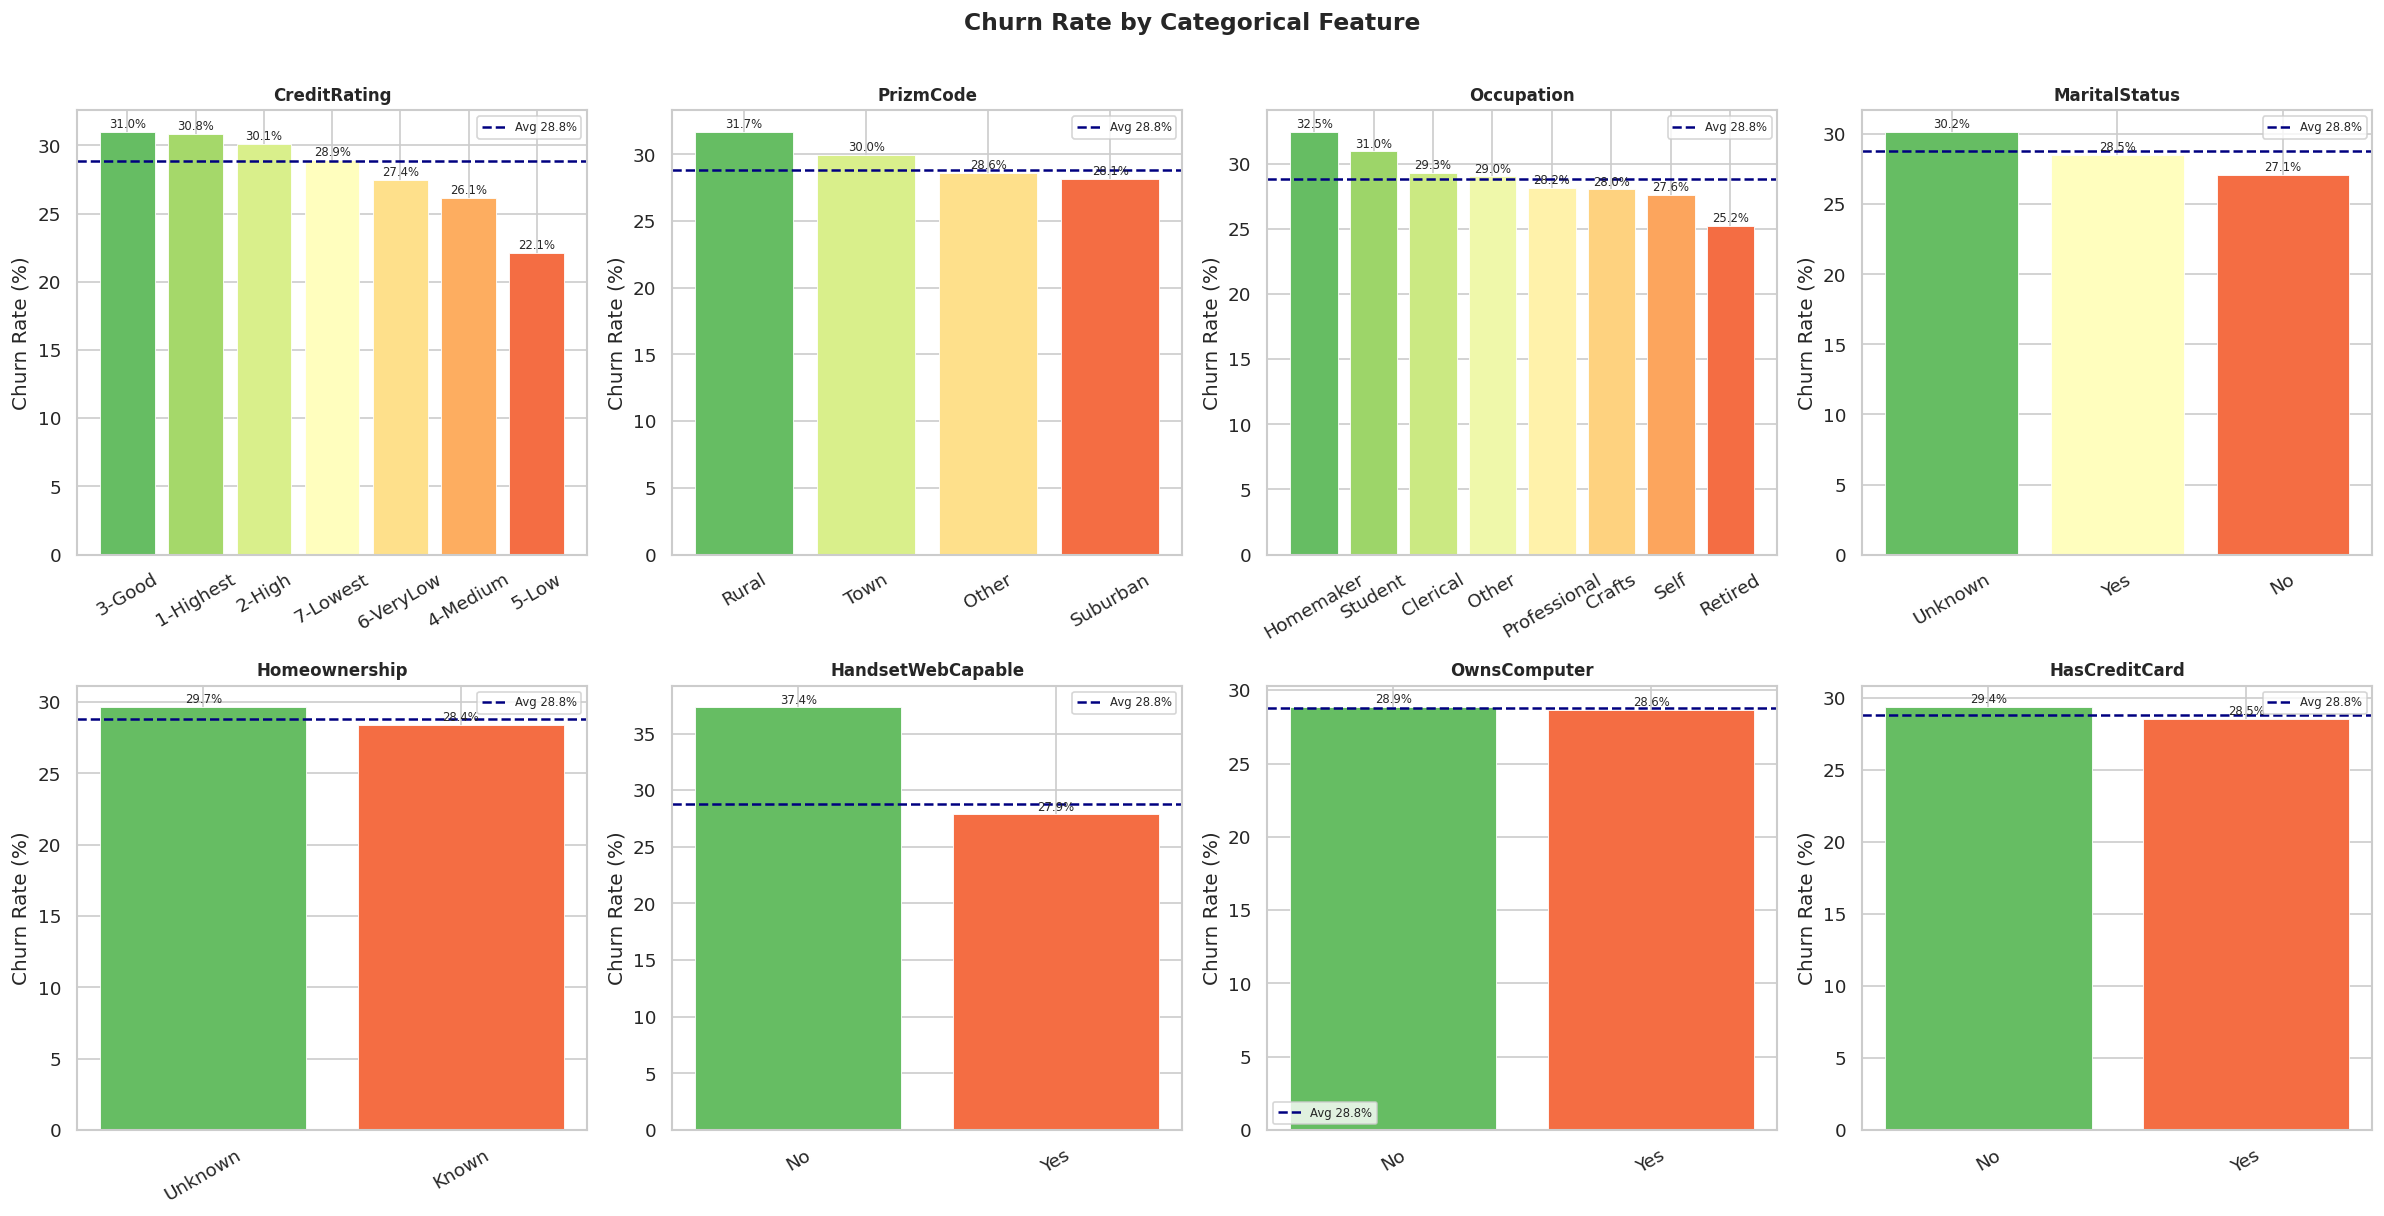

In [6]:
# ============================================================
# CELL 6: CHURN RATE BY CATEGORICAL FEATURES
# ============================================================
cat_features = ['CreditRating', 'PrizmCode', 'Occupation', 'MaritalStatus', 
                 'Homeownership', 'HandsetWebCapable', 'OwnsComputer', 'HasCreditCard']

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, col in enumerate(cat_features):
    churn_by_cat = df.groupby(col)['Churn'].apply(lambda x: (x=='Yes').mean()).sort_values(ascending=False)
    colors = plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, len(churn_by_cat)))
    bars = axes[i].bar(churn_by_cat.index, churn_by_cat.values * 100, color=colors, edgecolor='white', linewidth=0.5)
    axes[i].set_title(col, fontweight='bold', fontsize=10)
    axes[i].set_ylabel('Churn Rate (%)')
    axes[i].axhline(churn_rate * 100, color='navy', linestyle='--', linewidth=1.5, label=f'Avg {churn_rate:.1%}')
    axes[i].legend(fontsize=7)
    for bar, val in zip(bars, churn_by_cat.values):
        axes[i].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                     f'{val:.1%}', ha='center', fontsize=7)
    axes[i].tick_params(axis='x', rotation=30)

plt.suptitle('Churn Rate by Categorical Feature', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

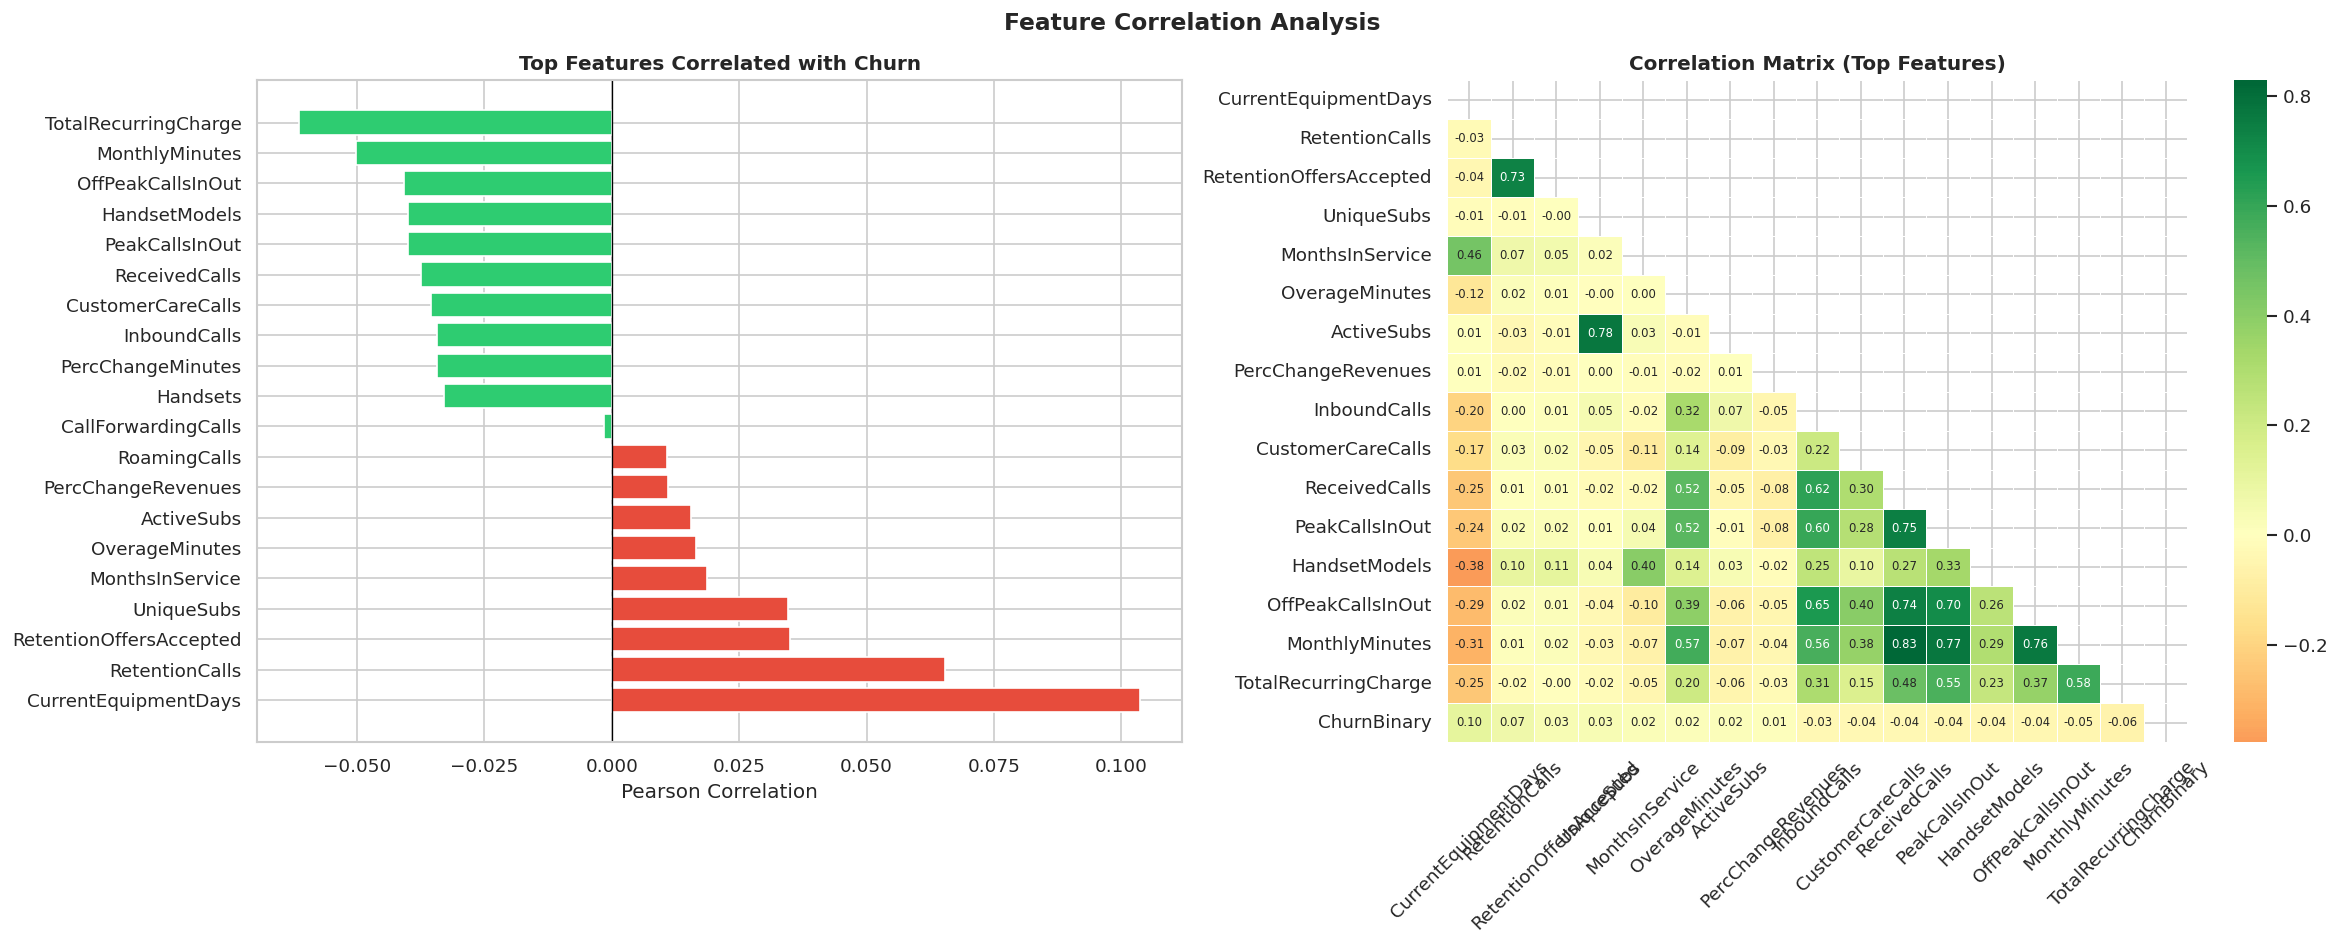

In [7]:
# ============================================================
# CELL 7: CORRELATION HEATMAP
# ============================================================
df_temp = df.copy()
df_temp['ChurnBinary'] = (df_temp['Churn'] == 'Yes').astype(int)

numeric_df = df_temp.select_dtypes(include=np.number).drop(['CustomerID'], axis=1, errors='ignore')
corr_with_target = numeric_df.corr()['ChurnBinary'].sort_values(ascending=False).drop('ChurnBinary')

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# Top correlations with churn
top_corr = pd.concat([corr_with_target.head(10), corr_with_target.tail(10)])
colors = ['#e74c3c' if x > 0 else '#2ecc71' for x in top_corr.values]
axes[0].barh(top_corr.index, top_corr.values, color=colors, edgecolor='white')
axes[0].axvline(0, color='black', linewidth=0.8)
axes[0].set_title('Top Features Correlated with Churn', fontweight='bold')
axes[0].set_xlabel('Pearson Correlation')

# Correlation heatmap of top correlated features
top_features = list(corr_with_target.head(8).index) + list(corr_with_target.tail(8).index) + ['ChurnBinary']
corr_matrix = numeric_df[top_features].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, ax=axes[1], annot_kws={'size': 7}, linewidths=0.5)
axes[1].set_title('Correlation Matrix (Top Features)', fontweight='bold')
axes[1].tick_params(axis='x', rotation=45)

plt.suptitle('Feature Correlation Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [8]:
# ============================================================
# CELL 8: ADVANCED EDA — RETENTION CALLS ANALYSIS
# ============================================================
fig = make_subplots(rows=1, cols=3,
    subplot_titles=('Revenue vs Minutes', 
                    'Churn by Months In Service',
                    'Customer Care Calls Distribution'))

for churn_val, color in [('No', '#2ecc71'), ('Yes', '#e74c3c')]:
    subset = df[df['Churn'] == churn_val].sample(1000, random_state=42)
    fig.add_trace(go.Scatter(
        x=subset['MonthlyMinutes'], y=subset['MonthlyRevenue'],
        mode='markers', name=f'Churn={churn_val}',
        marker=dict(color=color, opacity=0.5, size=4),
        showlegend=True
    ), row=1, col=1)

months_churn = df.groupby('MonthsInService')['Churn'].apply(lambda x: (x=='Yes').mean()).reset_index()
fig.add_trace(go.Bar(
    x=months_churn['MonthsInService'], y=months_churn['Churn'],
    marker_color='#3498db', name='Churn Rate by Tenure'
), row=1, col=2)

for churn_val, color in [('No', '#2ecc71'), ('Yes', '#e74c3c')]:
    data = df[df['Churn'] == churn_val]['CustomerCareCalls'].clip(0, 10)
    fig.add_trace(go.Box(
        y=data, name=f'Churn={churn_val}',
        marker_color=color, showlegend=False
    ), row=1, col=3)

fig.update_layout(
    title='<b>Key Business Metric Analysis</b>',
    height=500, template='plotly_white'
)
fig.show()

## 3. 🛠️ Feature Engineering

In [9]:
# ============================================================
# CELL 9: FEATURE ENGINEERING
# ============================================================
def engineer_features(df):
    df = df.copy()
    
    # --- Revenue & Usage Ratios ---
    df['RevenuePerMinute'] = df['MonthlyRevenue'] / (df['MonthlyMinutes'] + 1)
    df['ChargeRatio'] = df['TotalRecurringCharge'] / (df['MonthlyRevenue'] + 1)
    df['OverageRatio'] = df['OverageMinutes'] / (df['MonthlyMinutes'] + 1)
    df['RoamingRatio'] = df['RoamingCalls'] / (df['MonthlyMinutes'] + 1)
    
    # --- Call Quality Score ---
    df['CallQualityScore'] = -(df['DroppedCalls'] + df['BlockedCalls']) / (df['MonthlyMinutes'] + 1)
    df['DropBlockRatio'] = (df['DroppedCalls'] + df['BlockedCalls']) / (df['MonthlyMinutes'] + 1)
    
    # --- Customer Engagement ---
    df['TotalCallActivity'] = df['PeakCallsInOut'] + df['OffPeakCallsInOut']
    df['InOutRatio'] = df['InboundCalls'] / (df['OutboundCalls'] + 1)
    df['DirectAssistanceRatio'] = df['DirectorAssistedCalls'] / (df['MonthlyMinutes'] + 1)
    
    # --- Churn Risk Signals ---
    df['RetentionEngagement'] = df['RetentionCalls'] * df['RetentionOffersAccepted']
    df['CareCalls_PerMonth'] = df['CustomerCareCalls'] / (df['MonthsInService'] + 1)
    df['ThreewayCalls_Flag'] = (df['ThreewayCalls'] > 0).astype(int)
    
    # --- Device & Tenure ---
    df['HandsetAge_Months'] = df['CurrentEquipmentDays'] / 30
    df['AvgHandsetModels'] = df['HandsetModels'] / (df['Handsets'] + 1)
    df['TenureEquipmentRatio'] = df['MonthsInService'] / (df['CurrentEquipmentDays'] + 1)
    
    # --- Revenue Change Risk ---
    df['RevenueDecline'] = (df['PercChangeRevenues'] < -10).astype(int)
    df['MinutesDecline'] = (df['PercChangeMinutes'] < -20).astype(int)
    df['BothDecline'] = df['RevenueDecline'] * df['MinutesDecline']
    
    # --- Household Features ---
    df['HouseholdAdults'] = (df['AgeHH1'] > 0).astype(int) + (df['AgeHH2'] > 0).astype(int)
    df['AvgHouseholdAge'] = df[['AgeHH1', 'AgeHH2']].mean(axis=1)
    
    # --- HandsetPrice (fix Unknown) ---
    df['HandsetPrice_clean'] = pd.to_numeric(df['HandsetPrice'].replace('Unknown', np.nan))
    df['HandsetPrice_Unknown'] = (df['HandsetPrice'] == 'Unknown').astype(int)
    
    # --- Credit Rating ordinal ---
    credit_map = {'1-Highest': 7, '2-High': 6, '3-Good': 5, '4-Medium': 4, 
                  '5-Low': 3, '6-VeryLow': 2, '7-Lowest': 1}
    df['CreditScore'] = df['CreditRating'].map(credit_map)
    
    # --- Interaction features ---
    df['LowCredit_HighCare'] = ((df['CreditScore'] <= 3) & (df['CustomerCareCalls'] > 2)).astype(int)
    df['HighRetention_LowAccept'] = ((df['RetentionCalls'] > 0) & (df['RetentionOffersAccepted'] == 0)).astype(int)
    
    return df

df_feat = engineer_features(df)
new_features = set(df_feat.columns) - set(df.columns)
print(f'✅ Feature Engineering Complete!')
print(f'   Original features  : {df.shape[1]}')
print(f'   New features added : {len(new_features)}')
print(f'   Total features     : {df_feat.shape[1]}')
print(f'\n   New features: {sorted(new_features)}')

✅ Feature Engineering Complete!
   Original features  : 58
   New features added : 25
   Total features     : 83

   New features: ['AvgHandsetModels', 'AvgHouseholdAge', 'BothDecline', 'CallQualityScore', 'CareCalls_PerMonth', 'ChargeRatio', 'CreditScore', 'DirectAssistanceRatio', 'DropBlockRatio', 'HandsetAge_Months', 'HandsetPrice_Unknown', 'HandsetPrice_clean', 'HighRetention_LowAccept', 'HouseholdAdults', 'InOutRatio', 'LowCredit_HighCare', 'MinutesDecline', 'OverageRatio', 'RetentionEngagement', 'RevenueDecline', 'RevenuePerMinute', 'RoamingRatio', 'TenureEquipmentRatio', 'ThreewayCalls_Flag', 'TotalCallActivity']


## 4. ⚙️ Data Preprocessing Pipeline

In [10]:
# ============================================================
# CELL 10: PREPROCESSING
# ============================================================
def preprocess(df_feat, fit=True, encoders=None):
    df = df_feat.copy()
    
    drop_cols = ['CustomerID', 'Churn', 'ServiceArea', 'HandsetPrice', 'CreditRating']
    X = df.drop(columns=drop_cols, errors='ignore')
    y = (df['Churn'] == 'Yes').astype(int) if 'Churn' in df.columns else None
    
    binary_map = {'Yes': 1, 'No': 0, 'Unknown': -1, 'Known': 1}
    binary_cols = ['ChildrenInHH', 'HandsetRefurbished', 'HandsetWebCapable',
                   'TruckOwner', 'RVOwner', 'BuysViaMailOrder', 'RespondsToMailOffers',
                   'OptOutMailings', 'NonUSTravel', 'OwnsComputer', 'HasCreditCard',
                   'NewCellphoneUser', 'NotNewCellphoneUser', 'OwnsMotorcycle',
                   'MadeCallToRetentionTeam', 'MaritalStatus', 'Homeownership']
    
    for col in binary_cols:
        if col in X.columns:
            X[col] = X[col].map(binary_map).fillna(0)
    
    cat_remaining = X.select_dtypes('object').columns.tolist()
    if fit:
        encoders = {}
        for col in cat_remaining:
            le = LabelEncoder()
            X[col] = le.fit_transform(X[col].astype(str))
            encoders[col] = le
    else:
        for col in cat_remaining:
            if col in encoders:
                X[col] = X[col].astype(str).map(lambda x: encoders[col].transform([x])[0]
                                                  if x in encoders[col].classes_ else -1)
    
    # Replace inf/-inf from ratio features, then fill NaN with median
    X = X.replace([np.inf, -np.inf], np.nan)
    X = X.fillna(X.median(numeric_only=True))
    X = X.fillna(0)
    X = X.clip(-1e9, 1e9)
    
    return X, y, encoders

X, y, encoders = preprocess(df_feat, fit=True)

print(f'✅ Preprocessing complete!')
print(f'   Feature matrix: {X.shape}')
print(f'   Target distribution: {y.value_counts().to_dict()}')
print(f'   NaN remaining: {X.isnull().sum().sum()}')
print(f'   Inf remaining: {np.isinf(X.values).sum()}')


✅ Preprocessing complete!
   Feature matrix: (51047, 78)
   Target distribution: {0: 36336, 1: 14711}
   NaN remaining: 0
   Inf remaining: 0


In [11]:
# ============================================================
# CELL 11: TRAIN/VALIDATION/TEST SPLIT
# ============================================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.15, random_state=SEED, stratify=y_train
)

print('📊 Data Split Summary:')
print(f'   Train : {X_train.shape[0]:,} samples ({y_train.mean():.1%} churn)')
print(f'   Val   : {X_val.shape[0]:,} samples ({y_val.mean():.1%} churn)')
print(f'   Test  : {X_test.shape[0]:,} samples ({y_test.mean():.1%} churn)')
print(f'   Features: {X_train.shape[1]}')

# Scale for linear models
scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)

📊 Data Split Summary:
   Train : 34,711 samples (28.8% churn)
   Val   : 6,126 samples (28.8% churn)
   Test  : 10,210 samples (28.8% churn)
   Features: 78


## 5. 🤖 Model Training

In [12]:
# ============================================================
# CELL 12: BASELINE MODELS
# ============================================================
from sklearn.dummy import DummyClassifier

results = {}

def evaluate_model(name, model, X_tr, y_tr, X_v, y_v, X_te, y_te, scaled=False):
    if scaled:
        model.fit(X_tr, y_tr)
        prob_val = model.predict_proba(X_v)[:, 1]
        prob_test = model.predict_proba(X_te)[:, 1]
    else:
        model.fit(X_tr, y_tr)
        prob_val = model.predict_proba(X_v)[:, 1]
        prob_test = model.predict_proba(X_te)[:, 1]
    
    pred_val = (prob_val >= 0.5).astype(int)
    pred_test = (prob_test >= 0.5).astype(int)
    
    val_auc = roc_auc_score(y_v, prob_val)
    test_auc = roc_auc_score(y_te, prob_test)
    f1 = f1_score(y_te, pred_test)
    prec = precision_score(y_te, pred_test)
    rec = recall_score(y_te, pred_test)
    ap = average_precision_score(y_te, prob_test)
    
    results[name] = {
        'model': model,
        'val_auc': val_auc, 'test_auc': test_auc,
        'f1': f1, 'precision': prec, 'recall': rec,
        'avg_precision': ap,
        'prob_test': prob_test
    }
    print(f'  {name:35s} | Val AUC: {val_auc:.4f} | Test AUC: {test_auc:.4f} | F1: {f1:.4f} | AP: {ap:.4f}')
    return model

print('🚀 Training Baseline Models...')
print(f'{"Model":35s} | Val AUC | Test AUC | F1     | Avg Prec')
print('-'*80)

# Logistic Regression
lr = LogisticRegression(C=0.1, class_weight='balanced', max_iter=1000, random_state=SEED)
evaluate_model('Logistic Regression', lr, X_train_scaled, y_train, X_val_scaled, y_val, X_test_scaled, y_test, scaled=True)

# Random Forest
rf = RandomForestClassifier(n_estimators=300, max_depth=12, min_samples_leaf=20,
                            class_weight='balanced', random_state=SEED, n_jobs=-1)
evaluate_model('Random Forest', rf, X_train, y_train, X_val, y_val, X_test, y_test)

# XGBoost
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
xgb_model = xgb.XGBClassifier(
    n_estimators=500, learning_rate=0.05, max_depth=6,
    subsample=0.8, colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    eval_metric='auc', random_state=SEED,
    early_stopping_rounds=50, verbosity=0
)
xgb_model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
xgb_prob_val = xgb_model.predict_proba(X_val)[:, 1]
xgb_prob_test = xgb_model.predict_proba(X_test)[:, 1]
xgb_pred_test = (xgb_prob_test >= 0.5).astype(int)
results['XGBoost'] = {
    'model': xgb_model,
    'val_auc': roc_auc_score(y_val, xgb_prob_val),
    'test_auc': roc_auc_score(y_test, xgb_prob_test),
    'f1': f1_score(y_test, xgb_pred_test),
    'precision': precision_score(y_test, xgb_pred_test),
    'recall': recall_score(y_test, xgb_pred_test),
    'avg_precision': average_precision_score(y_test, xgb_prob_test),
    'prob_test': xgb_prob_test
}
print(f'  {"XGBoost":35s} | Val AUC: {results["XGBoost"]["val_auc"]:.4f} | Test AUC: {results["XGBoost"]["test_auc"]:.4f} | F1: {results["XGBoost"]["f1"]:.4f} | AP: {results["XGBoost"]["avg_precision"]:.4f}')

# LightGBM
lgbm = lgb.LGBMClassifier(
    n_estimators=1000, learning_rate=0.05, max_depth=8,
    num_leaves=63, subsample=0.8, colsample_bytree=0.8,
    class_weight='balanced', random_state=SEED, verbose=-1,
    early_stopping_round=50
)
lgbm.fit(X_train, y_train, eval_set=[(X_val, y_val)], callbacks=[lgb.log_evaluation(period=-1)])
lgbm_prob_val = lgbm.predict_proba(X_val)[:, 1]
lgbm_prob_test = lgbm.predict_proba(X_test)[:, 1]
lgbm_pred_test = (lgbm_prob_test >= 0.5).astype(int)
results['LightGBM'] = {
    'model': lgbm,
    'val_auc': roc_auc_score(y_val, lgbm_prob_val),
    'test_auc': roc_auc_score(y_test, lgbm_prob_test),
    'f1': f1_score(y_test, lgbm_pred_test),
    'precision': precision_score(y_test, lgbm_pred_test),
    'recall': recall_score(y_test, lgbm_pred_test),
    'avg_precision': average_precision_score(y_test, lgbm_prob_test),
    'prob_test': lgbm_prob_test
}
print(f'  {"LightGBM":35s} | Val AUC: {results["LightGBM"]["val_auc"]:.4f} | Test AUC: {results["LightGBM"]["test_auc"]:.4f} | F1: {results["LightGBM"]["f1"]:.4f} | AP: {results["LightGBM"]["avg_precision"]:.4f}')

🚀 Training Baseline Models...
Model                               | Val AUC | Test AUC | F1     | Avg Prec
--------------------------------------------------------------------------------


  Logistic Regression                 | Val AUC: 0.6318 | Test AUC: 0.6263 | F1: 0.4530 | AP: 0.3958


  Random Forest                       | Val AUC: 0.6686 | Test AUC: 0.6615 | F1: 0.4780 | AP: 0.4333


  XGBoost                             | Val AUC: 0.6796 | Test AUC: 0.6771 | F1: 0.4914 | AP: 0.4547


  LightGBM                            | Val AUC: 0.6690 | Test AUC: 0.6706 | F1: 0.4561 | AP: 0.4439


## 6. 🔧 Hyperparameter Tuning with Optuna

In [13]:
# ============================================================
# CELL 13: OPTUNA TUNING — XGBoost
# ============================================================
print('🔧 Optuna Hyperparameter Tuning — XGBoost (50 trials)...')

def xgb_objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 200, 1000),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'max_depth': trial.suggest_int('max_depth', 4, 10),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 20),
        'gamma': trial.suggest_float('gamma', 0, 5),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        'scale_pos_weight': scale_pos_weight,
        'eval_metric': 'auc',
        'random_state': SEED,
        'verbosity': 0
    }
    model = xgb.XGBClassifier(**params, early_stopping_rounds=30)
    model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
    preds = model.predict_proba(X_val)[:, 1]
    return roc_auc_score(y_val, preds)

study_xgb = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=SEED))
study_xgb.optimize(xgb_objective, n_trials=50, show_progress_bar=True)

print(f'\n✅ Best XGBoost Val AUC: {study_xgb.best_value:.4f}')
print(f'   Best params: {study_xgb.best_params}')

🔧 Optuna Hyperparameter Tuning — XGBoost (50 trials)...


  0%|          | 0/50 [00:00<?, ?it/s]


✅ Best XGBoost Val AUC: 0.6863
   Best params: {'n_estimators': 291, 'learning_rate': 0.038290966039329986, 'max_depth': 5, 'subsample': 0.7400841763541415, 'colsample_bytree': 0.7089388926177855, 'min_child_weight': 17, 'gamma': 2.8126148864124505, 'reg_alpha': 5.570907652570733e-08, 'reg_lambda': 0.0001088136231728193}


In [14]:
# ============================================================
# CELL 14: OPTUNA TUNING — LightGBM
# ============================================================
print('🔧 Optuna Hyperparameter Tuning — LightGBM (50 trials)...')

def lgbm_objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 200, 2000),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'max_depth': trial.suggest_int('max_depth', 4, 12),
        'num_leaves': trial.suggest_int('num_leaves', 20, 200),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 100),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        'class_weight': 'balanced',
        'random_state': SEED,
        'verbose': -1,
        'early_stopping_round': 30
    }
    model = lgb.LGBMClassifier(**params)
    model.fit(X_train, y_train, eval_set=[(X_val, y_val)], callbacks=[lgb.log_evaluation(period=-1)])
    preds = model.predict_proba(X_val)[:, 1]
    return roc_auc_score(y_val, preds)

study_lgbm = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=SEED))
study_lgbm.optimize(lgbm_objective, n_trials=50, show_progress_bar=True)

print(f'\n✅ Best LightGBM Val AUC: {study_lgbm.best_value:.4f}')
print(f'   Best params: {study_lgbm.best_params}')

🔧 Optuna Hyperparameter Tuning — LightGBM (50 trials)...


  0%|          | 0/50 [00:00<?, ?it/s]


✅ Best LightGBM Val AUC: 0.6870
   Best params: {'n_estimators': 1559, 'learning_rate': 0.015962914687028068, 'max_depth': 4, 'num_leaves': 171, 'subsample': 0.6931557127148463, 'colsample_bytree': 0.6125608018170263, 'min_child_samples': 5, 'reg_alpha': 5.3239573039646596e-06, 'reg_lambda': 3.2750340953417674e-07}


In [15]:
# ============================================================
# CELL 15: TRAIN TUNED MODELS & EVALUATE
# ============================================================
print('🏋️ Training tuned models on full train set...')

# Best XGBoost
best_xgb_params = study_xgb.best_params.copy()
best_xgb_params.update({'scale_pos_weight': scale_pos_weight, 'eval_metric': 'auc',
                         'random_state': SEED, 'verbosity': 0})
xgb_tuned = xgb.XGBClassifier(**best_xgb_params, early_stopping_rounds=50)
xgb_tuned.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
xgb_tuned_prob_test = xgb_tuned.predict_proba(X_test)[:, 1]
xgb_tuned_pred_test = (xgb_tuned_prob_test >= 0.5).astype(int)
results['XGBoost (Tuned)'] = {
    'model': xgb_tuned,
    'val_auc': study_xgb.best_value,
    'test_auc': roc_auc_score(y_test, xgb_tuned_prob_test),
    'f1': f1_score(y_test, xgb_tuned_pred_test),
    'precision': precision_score(y_test, xgb_tuned_pred_test),
    'recall': recall_score(y_test, xgb_tuned_pred_test),
    'avg_precision': average_precision_score(y_test, xgb_tuned_prob_test),
    'prob_test': xgb_tuned_prob_test
}

# Best LightGBM
best_lgbm_params = study_lgbm.best_params.copy()
best_lgbm_params.update({'class_weight': 'balanced', 'random_state': SEED, 
                          'verbose': -1, 'early_stopping_round': 50})
lgbm_tuned = lgb.LGBMClassifier(**best_lgbm_params)
lgbm_tuned.fit(X_train, y_train, eval_set=[(X_val, y_val)], callbacks=[lgb.log_evaluation(period=-1)])
lgbm_tuned_prob_test = lgbm_tuned.predict_proba(X_test)[:, 1]
lgbm_tuned_pred_test = (lgbm_tuned_prob_test >= 0.5).astype(int)
results['LightGBM (Tuned)'] = {
    'model': lgbm_tuned,
    'val_auc': study_lgbm.best_value,
    'test_auc': roc_auc_score(y_test, lgbm_tuned_prob_test),
    'f1': f1_score(y_test, lgbm_tuned_pred_test),
    'precision': precision_score(y_test, lgbm_tuned_pred_test),
    'recall': recall_score(y_test, lgbm_tuned_pred_test),
    'avg_precision': average_precision_score(y_test, lgbm_tuned_prob_test),
    'prob_test': lgbm_tuned_prob_test
}

print(f'\n✅ XGBoost Tuned Test AUC : {results["XGBoost (Tuned)"]["test_auc"]:.4f}')
print(f'✅ LightGBM Tuned Test AUC: {results["LightGBM (Tuned)"]["test_auc"]:.4f}')

🏋️ Training tuned models on full train set...



✅ XGBoost Tuned Test AUC : 0.6804
✅ LightGBM Tuned Test AUC: 0.6810


## 7. 🏆 Ensemble Model

In [16]:
# ============================================================
# CELL 16: ENSEMBLE (WEIGHTED AVERAGE)
# ============================================================
# Blend top models using val AUC as weights
ensemble_models = ['XGBoost (Tuned)', 'LightGBM (Tuned)', 'Random Forest']
val_aucs = np.array([results[m]['val_auc'] for m in ensemble_models])
weights = val_aucs / val_aucs.sum()

ensemble_prob_test = np.zeros(len(y_test))
for m, w in zip(ensemble_models, weights):
    ensemble_prob_test += w * results[m]['prob_test']

ensemble_pred_test = (ensemble_prob_test >= 0.5).astype(int)
ensemble_auc = roc_auc_score(y_test, ensemble_prob_test)

results['Ensemble (Weighted Avg)'] = {
    'model': None,
    'val_auc': np.dot(val_aucs, weights),
    'test_auc': ensemble_auc,
    'f1': f1_score(y_test, ensemble_pred_test),
    'precision': precision_score(y_test, ensemble_pred_test),
    'recall': recall_score(y_test, ensemble_pred_test),
    'avg_precision': average_precision_score(y_test, ensemble_prob_test),
    'prob_test': ensemble_prob_test
}

print('🏆 Ensemble Model Results:')
print(f'   Weights: {dict(zip(ensemble_models, weights.round(3)))}')
for m in ['XGBoost (Tuned)', 'LightGBM (Tuned)', 'Random Forest', 'Ensemble (Weighted Avg)']:
    r = results[m]
    print(f'   {m:35s} AUC={r["test_auc"]:.4f}  F1={r["f1"]:.4f}  AP={r["avg_precision"]:.4f}')

🏆 Ensemble Model Results:
   Weights: {'XGBoost (Tuned)': np.float64(0.336), 'LightGBM (Tuned)': np.float64(0.336), 'Random Forest': np.float64(0.327)}
   XGBoost (Tuned)                     AUC=0.6804  F1=0.4991  AP=0.4550
   LightGBM (Tuned)                    AUC=0.6810  F1=0.4945  AP=0.4567
   Random Forest                       AUC=0.6615  F1=0.4780  AP=0.4333
   Ensemble (Weighted Avg)             AUC=0.6799  F1=0.4967  AP=0.4554


## 8. 📈 Model Evaluation & Comparison

📊 Model Performance Summary:


,Model,Test AUC,F1,Precision,Recall,Avg Precision
5,LightGBM (Tuned),0.6810,0.4945,0.4068,0.6302,0.4567
4,XGBoost (Tuned),0.6804,0.4991,0.4083,0.6421,0.4550
6,Ensemble (Weighted Avg),0.6799,0.4967,0.4096,0.6309,0.4554
2,XGBoost,0.6771,0.4914,0.4072,0.6193,0.4547
3,LightGBM,0.6706,0.4561,0.4375,0.4762,0.4439
1,Random Forest,0.6615,0.4780,0.4003,0.5931,0.4333
0,Logistic Regression,0.6263,0.4530,0.3729,0.5768,0.3958


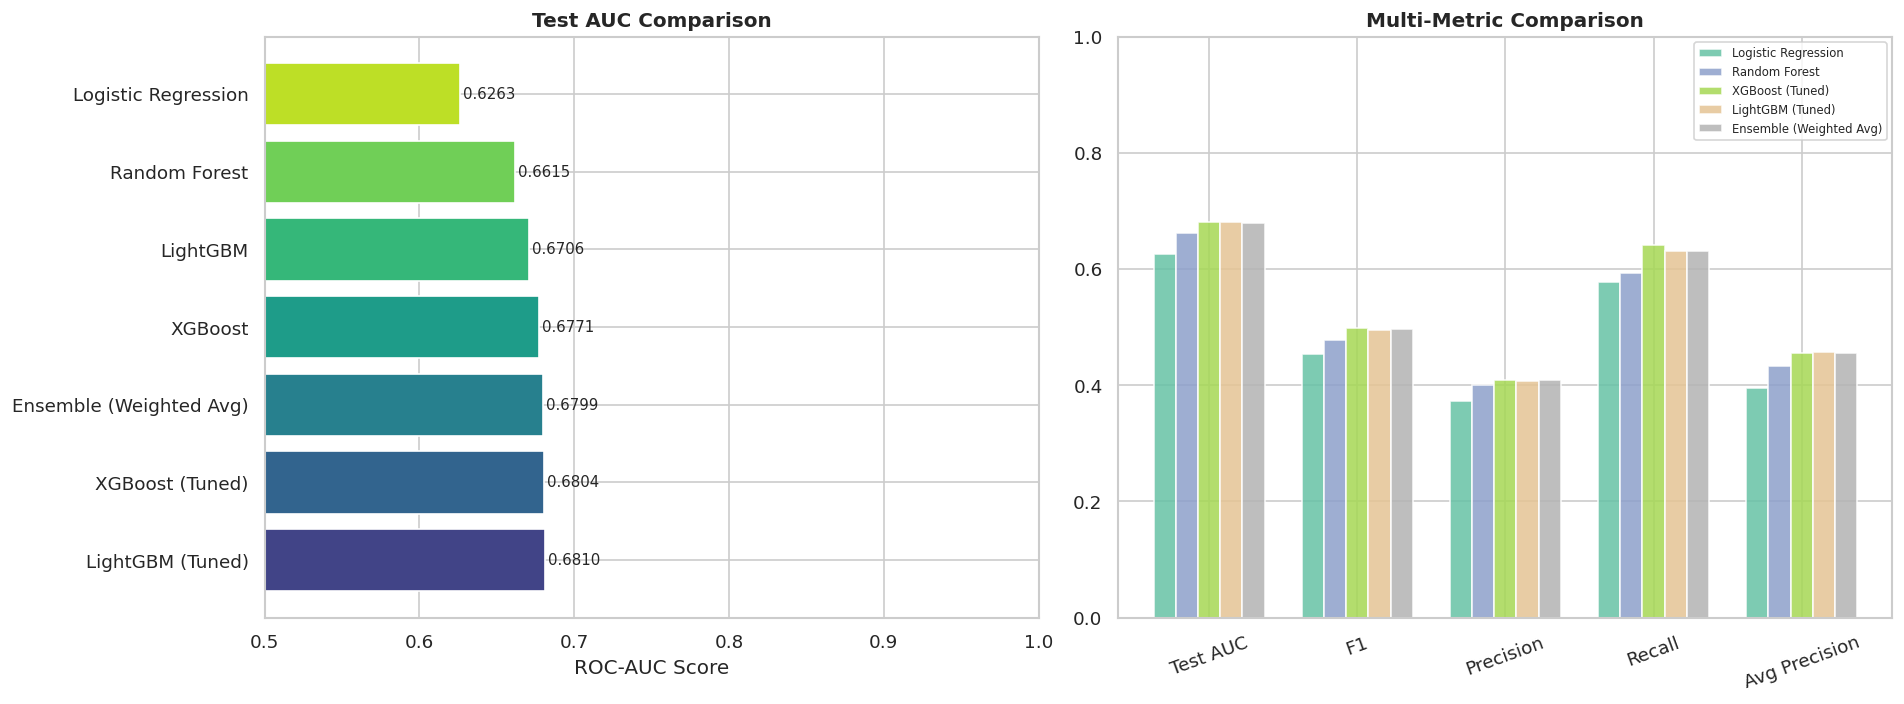

In [17]:
# ============================================================
# CELL 17: MODEL COMPARISON DASHBOARD
# ============================================================
metrics_df = pd.DataFrame([
    {'Model': name, 'Test AUC': r['test_auc'], 'F1': r['f1'],
     'Precision': r['precision'], 'Recall': r['recall'], 'Avg Precision': r['avg_precision']}
    for name, r in results.items()
]).sort_values('Test AUC', ascending=False)

print('📊 Model Performance Summary:')
display(metrics_df.style
    .background_gradient(subset=['Test AUC', 'F1', 'Avg Precision'], cmap='Greens')
    .format(precision=4)
    .set_caption('All Models — Test Set Performance'))

# Visual comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

colors = plt.cm.viridis(np.linspace(0.2, 0.9, len(metrics_df)))
bars = axes[0].barh(metrics_df['Model'], metrics_df['Test AUC'], color=colors, edgecolor='white')
axes[0].set_xlim(0.5, 1.0)
axes[0].set_xlabel('ROC-AUC Score')
axes[0].set_title('Test AUC Comparison', fontweight='bold')
for bar, val in zip(bars, metrics_df['Test AUC']):
    axes[0].text(val + 0.002, bar.get_y() + bar.get_height()/2, f'{val:.4f}', va='center', fontsize=9)

metric_cols = ['Test AUC', 'F1', 'Precision', 'Recall', 'Avg Precision']
x = np.arange(len(metric_cols))
width = 0.15
plot_models = ['Logistic Regression', 'Random Forest', 'XGBoost (Tuned)', 'LightGBM (Tuned)', 'Ensemble (Weighted Avg)']
colors2 = plt.cm.Set2(np.linspace(0, 1, len(plot_models)))
for i, (model, color) in enumerate(zip(plot_models, colors2)):
    row = metrics_df[metrics_df['Model'] == model]
    if len(row) > 0:
        vals = [row[m].values[0] for m in metric_cols]
        axes[1].bar(x + i*width, vals, width, label=model, color=color, alpha=0.85)
axes[1].set_xticks(x + width * 2)
axes[1].set_xticklabels(metric_cols, rotation=20)
axes[1].set_ylim(0, 1)
axes[1].legend(fontsize=7)
axes[1].set_title('Multi-Metric Comparison', fontweight='bold')

plt.tight_layout()
plt.show()

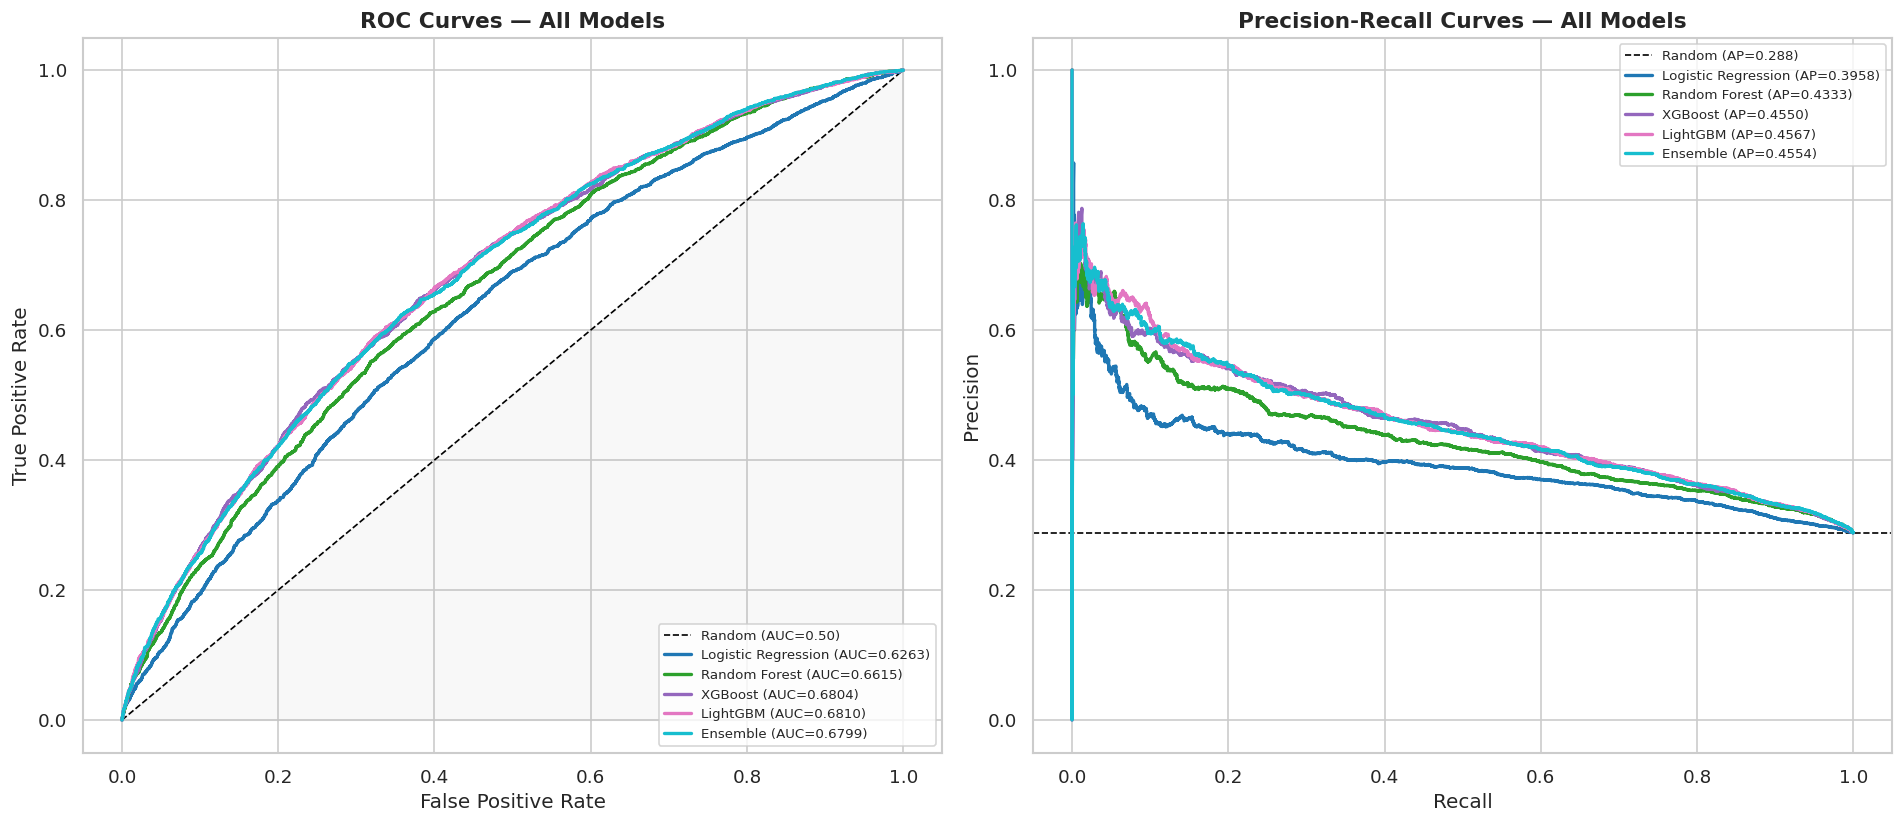

In [18]:
# ============================================================
# CELL 18: ROC CURVES & PRECISION-RECALL CURVES
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

plot_models = ['Logistic Regression', 'Random Forest', 'XGBoost (Tuned)', 'LightGBM (Tuned)', 'Ensemble (Weighted Avg)']
colors_roc = plt.cm.tab10(np.linspace(0, 0.9, len(plot_models)))

# ROC Curves
axes[0].plot([0,1],[0,1], 'k--', linewidth=1, label='Random (AUC=0.50)')
for model_name, color in zip(plot_models, colors_roc):
    r = results[model_name]
    fpr, tpr, _ = roc_curve(y_test, r['prob_test'])
    axes[0].plot(fpr, tpr, linewidth=2, color=color,
                 label=f"{model_name.split(' (')[0]} (AUC={r['test_auc']:.4f})")
axes[0].set_xlabel('False Positive Rate', fontsize=12)
axes[0].set_ylabel('True Positive Rate', fontsize=12)
axes[0].set_title('ROC Curves — All Models', fontweight='bold', fontsize=13)
axes[0].legend(fontsize=8, loc='lower right')
axes[0].fill_between([0,1],[0,0],[0,1], alpha=0.05, color='gray')

# Precision-Recall Curves
baseline_precision = y_test.mean()
axes[1].axhline(baseline_precision, color='k', linestyle='--', linewidth=1, label=f'Random (AP={baseline_precision:.3f})')
for model_name, color in zip(plot_models, colors_roc):
    r = results[model_name]
    prec, rec, _ = precision_recall_curve(y_test, r['prob_test'])
    axes[1].plot(rec, prec, linewidth=2, color=color,
                 label=f"{model_name.split(' (')[0]} (AP={r['avg_precision']:.4f})")
axes[1].set_xlabel('Recall', fontsize=12)
axes[1].set_ylabel('Precision', fontsize=12)
axes[1].set_title('Precision-Recall Curves — All Models', fontweight='bold', fontsize=13)
axes[1].legend(fontsize=8, loc='upper right')

plt.tight_layout()
plt.savefig('roc_pr_curves.png', dpi=150, bbox_inches='tight')
plt.show()

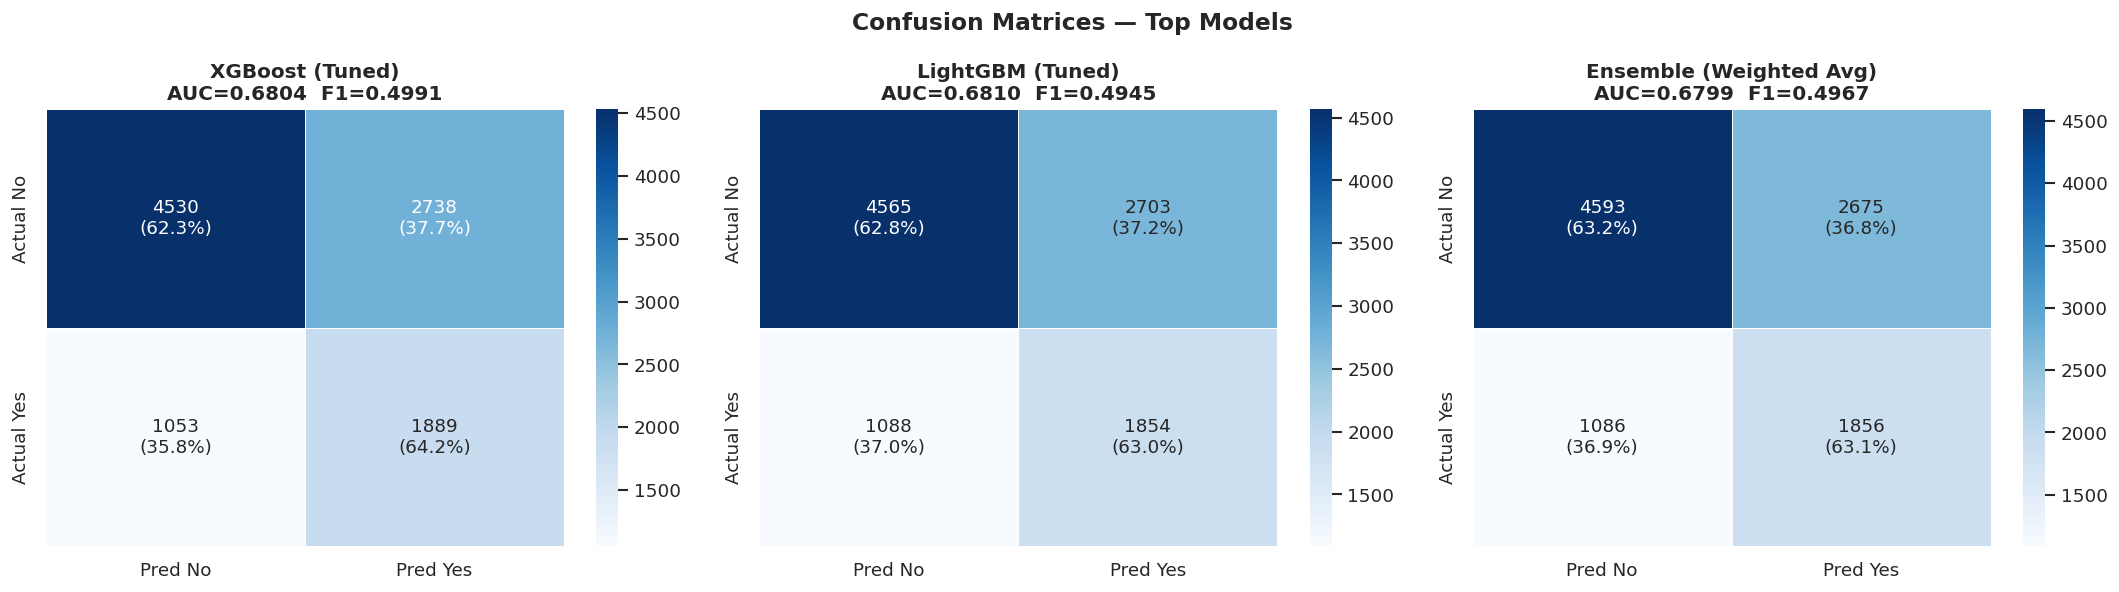

In [19]:
# ============================================================
# CELL 19: CONFUSION MATRICES — TOP 3 MODELS
# ============================================================
top_models = ['XGBoost (Tuned)', 'LightGBM (Tuned)', 'Ensemble (Weighted Avg)']
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, model_name in enumerate(top_models):
    r = results[model_name]
    pred = (r['prob_test'] >= 0.5).astype(int)
    cm = confusion_matrix(y_test, pred)
    cm_pct = cm / cm.sum(axis=1, keepdims=True)
    
    annot = np.array([[f'{cm[i,j]}\n({cm_pct[i,j]:.1%})' for j in range(2)] for i in range(2)])
    sns.heatmap(cm, annot=annot, fmt='', cmap='Blues', ax=axes[i],
                xticklabels=['Pred No', 'Pred Yes'],
                yticklabels=['Actual No', 'Actual Yes'],
                linewidths=0.5, annot_kws={'size': 11})
    axes[i].set_title(f'{model_name}\nAUC={r["test_auc"]:.4f}  F1={r["f1"]:.4f}', fontweight='bold')

plt.suptitle('Confusion Matrices — Top Models', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

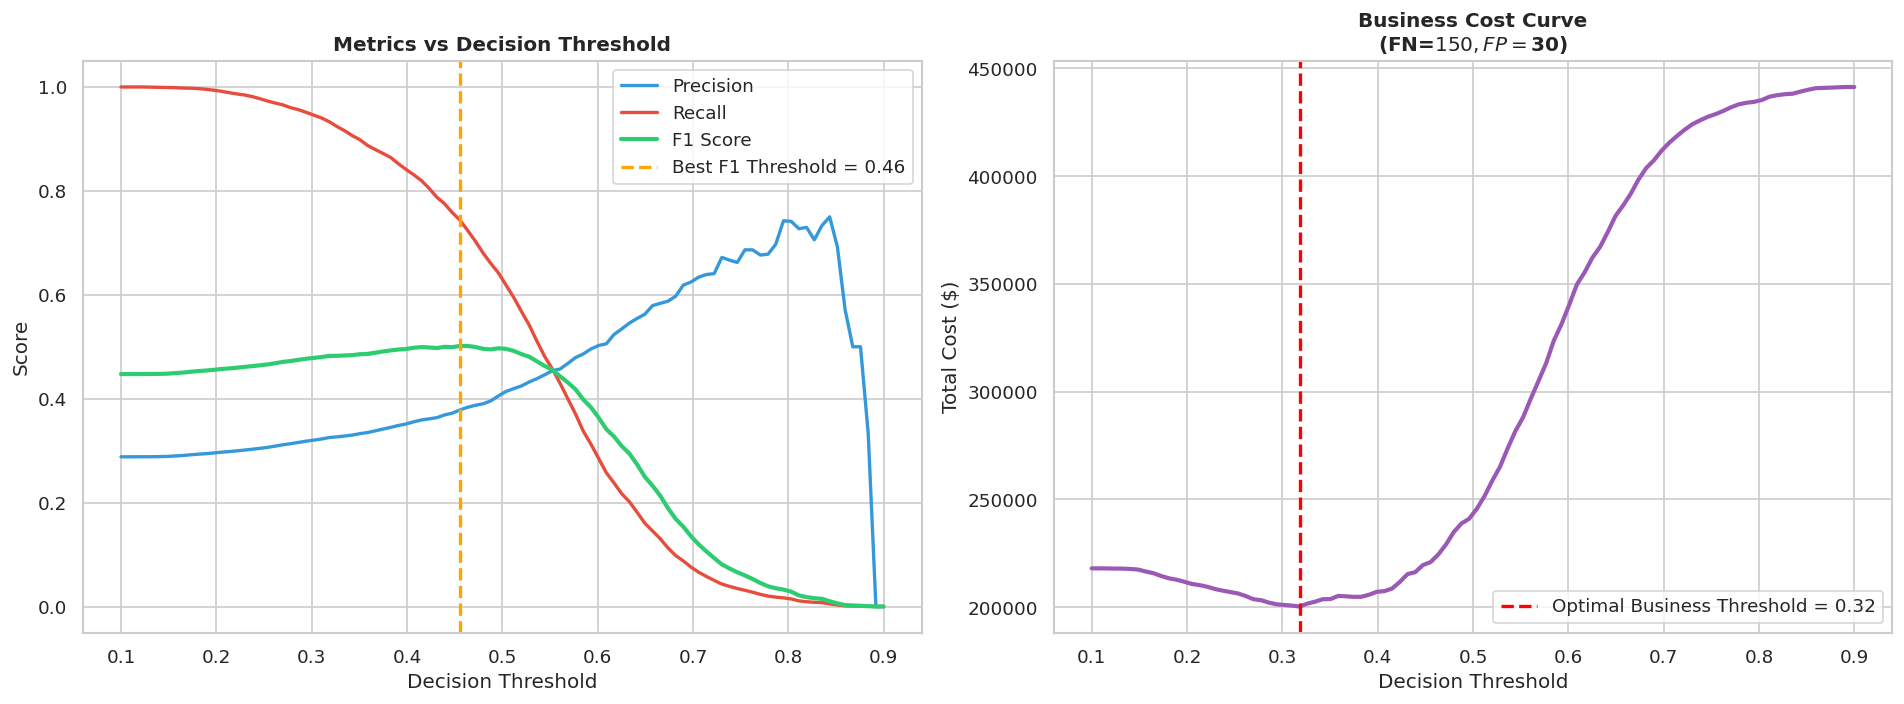

🎯 Optimal F1 Threshold      : 0.46  →  F1=0.5015
💰 Optimal Business Threshold: 0.32  →  Cost=$200,340


In [20]:
# ============================================================
# CELL 20: THRESHOLD ANALYSIS
# ============================================================
best_model_name = 'Ensemble (Weighted Avg)'
best_probs = results[best_model_name]['prob_test']

thresholds = np.linspace(0.1, 0.9, 100)
precisions, recalls, f1s, accuracies = [], [], [], []

for t in thresholds:
    pred = (best_probs >= t).astype(int)
    precisions.append(precision_score(y_test, pred, zero_division=0))
    recalls.append(recall_score(y_test, pred))
    f1s.append(f1_score(y_test, pred))
    accuracies.append(accuracy_score(y_test, pred))

best_f1_thresh = thresholds[np.argmax(f1s)]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

ax1.plot(thresholds, precisions, label='Precision', color='#3498db', linewidth=2)
ax1.plot(thresholds, recalls, label='Recall', color='#e74c3c', linewidth=2)
ax1.plot(thresholds, f1s, label='F1 Score', color='#2ecc71', linewidth=2.5)
ax1.axvline(best_f1_thresh, color='orange', linestyle='--', linewidth=2,
            label=f'Best F1 Threshold = {best_f1_thresh:.2f}')
ax1.set_xlabel('Decision Threshold')
ax1.set_ylabel('Score')
ax1.set_title('Metrics vs Decision Threshold', fontweight='bold')
ax1.legend()

# Business cost curve
cost_fn = 150   # cost of false negative (miss a churner)
cost_fp = 30    # cost of false positive (unnecessary retention offer)
business_costs = []
for t in thresholds:
    pred = (best_probs >= t).astype(int)
    cm = confusion_matrix(y_test, pred)
    tn, fp, fn, tp = cm.ravel()
    cost = fn * cost_fn + fp * cost_fp
    business_costs.append(cost)

best_biz_thresh = thresholds[np.argmin(business_costs)]
ax2.plot(thresholds, business_costs, color='#9b59b6', linewidth=2.5)
ax2.axvline(best_biz_thresh, color='red', linestyle='--', linewidth=2,
            label=f'Optimal Business Threshold = {best_biz_thresh:.2f}')
ax2.set_xlabel('Decision Threshold')
ax2.set_ylabel('Total Cost ($)')
ax2.set_title(f'Business Cost Curve\n(FN=${cost_fn}, FP=${cost_fp})', fontweight='bold')
ax2.legend()

plt.tight_layout()
plt.show()

print(f'🎯 Optimal F1 Threshold      : {best_f1_thresh:.2f}  →  F1={max(f1s):.4f}')
print(f'💰 Optimal Business Threshold: {best_biz_thresh:.2f}  →  Cost=${min(business_costs):,.0f}')

## 9. 🔍 Feature Importance & Interpretability

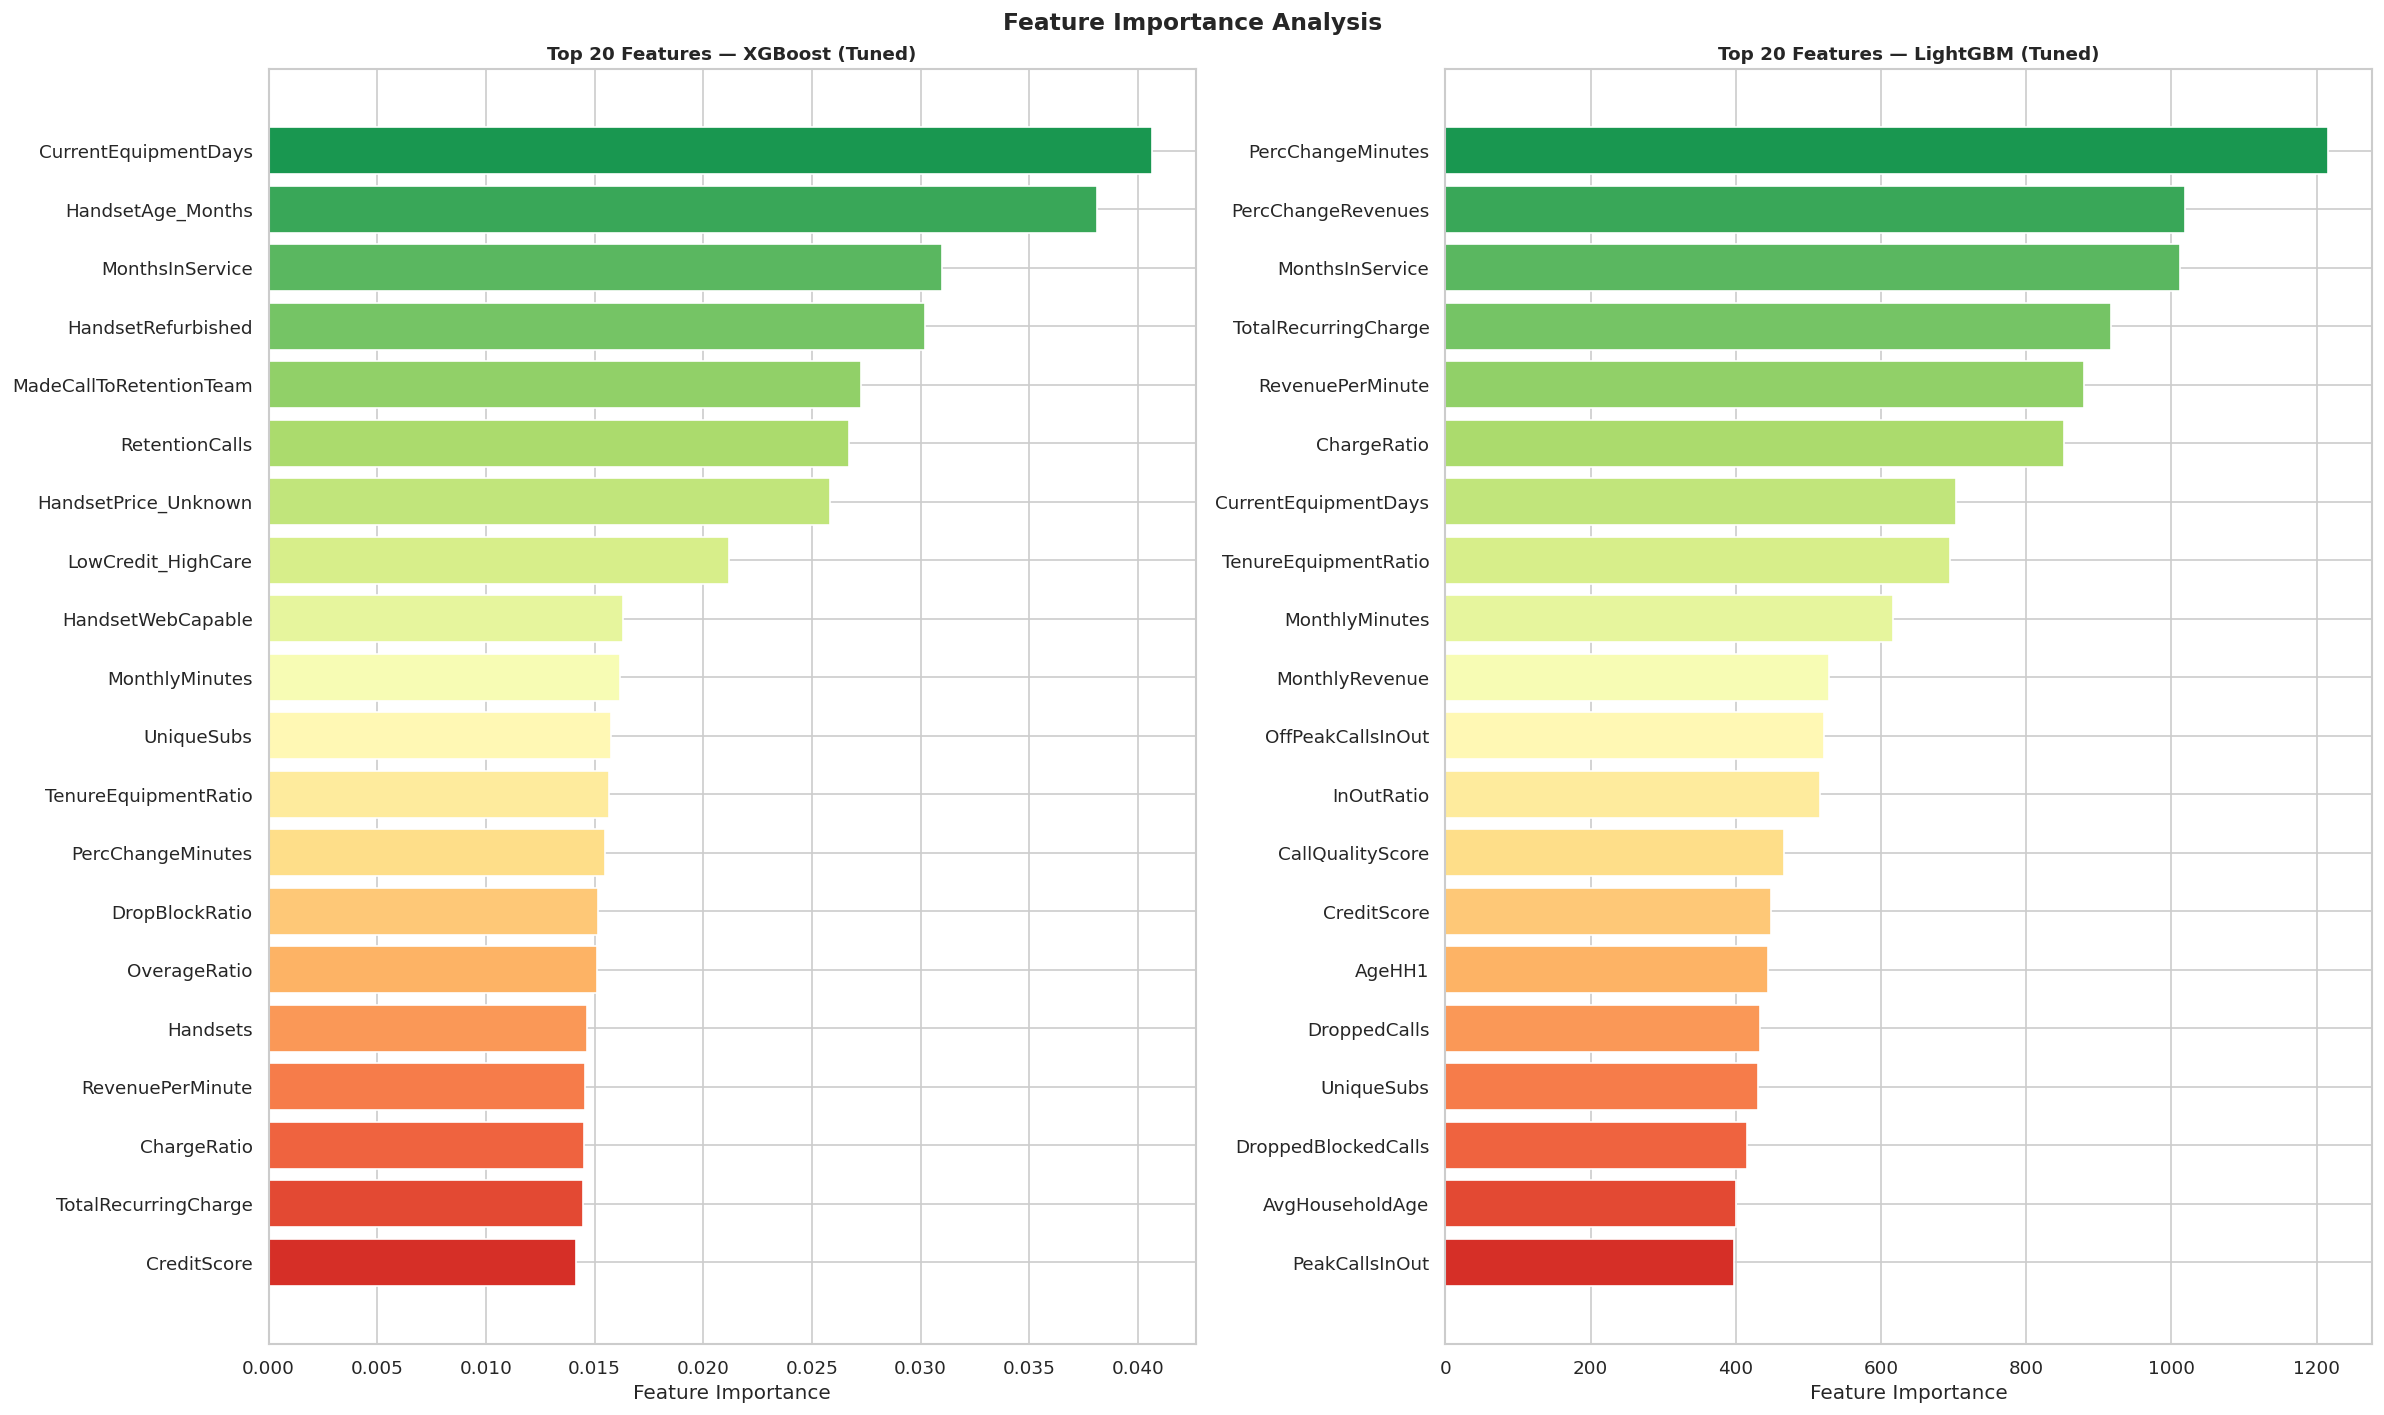

In [21]:
# ============================================================
# CELL 21: FEATURE IMPORTANCE — XGBoost & LightGBM
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(20, 12))

for ax, model_name, model_obj in [
    (axes[0], 'XGBoost (Tuned)', results['XGBoost (Tuned)']['model']),
    (axes[1], 'LightGBM (Tuned)', results['LightGBM (Tuned)']['model'])
]:
    if hasattr(model_obj, 'feature_importances_'):
        imp = pd.Series(model_obj.feature_importances_, index=X.columns)
        top20 = imp.nlargest(20)
        colors = plt.cm.RdYlGn_r(np.linspace(0.1, 0.9, len(top20)))
        bars = ax.barh(top20.index[::-1], top20.values[::-1], color=colors[::-1], edgecolor='white')
        ax.set_title(f'Top 20 Features — {model_name}', fontweight='bold', fontsize=11)
        ax.set_xlabel('Feature Importance')

plt.suptitle('Feature Importance Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

⏳ Computing permutation importance (this may take a moment)...


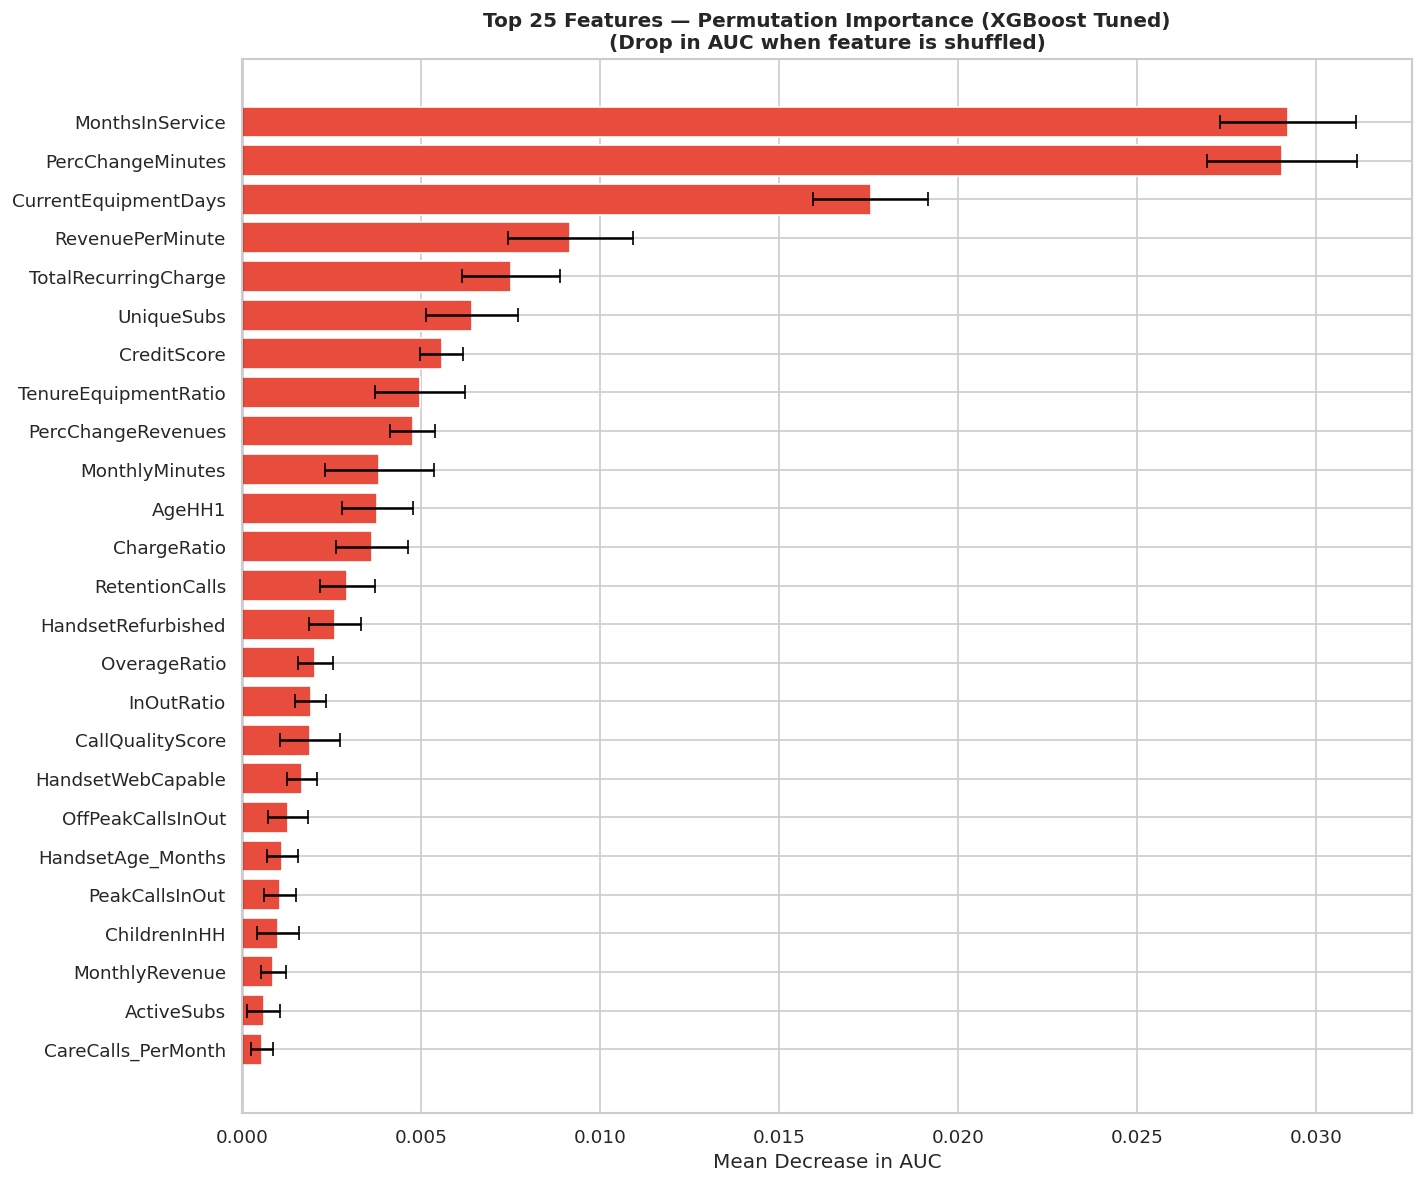

In [22]:
# ============================================================
# CELL 22: PERMUTATION IMPORTANCE
# ============================================================
print('⏳ Computing permutation importance (this may take a moment)...')
perm_imp = permutation_importance(
    results['XGBoost (Tuned)']['model'], X_test, y_test,
    n_repeats=10, random_state=SEED, scoring='roc_auc', n_jobs=-1
)

perm_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': perm_imp.importances_mean,
    'Std': perm_imp.importances_std
}).sort_values('Importance', ascending=False).head(25)

fig, ax = plt.subplots(figsize=(12, 10))
colors = ['#e74c3c' if x > 0 else '#95a5a6' for x in perm_df['Importance']]
ax.barh(perm_df['Feature'][::-1], perm_df['Importance'][::-1],
        xerr=perm_df['Std'][::-1], color=colors[::-1], capsize=4, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Top 25 Features — Permutation Importance (XGBoost Tuned)\n(Drop in AUC when feature is shuffled)',
             fontweight='bold', fontsize=12)
ax.set_xlabel('Mean Decrease in AUC')
plt.tight_layout()
plt.show()

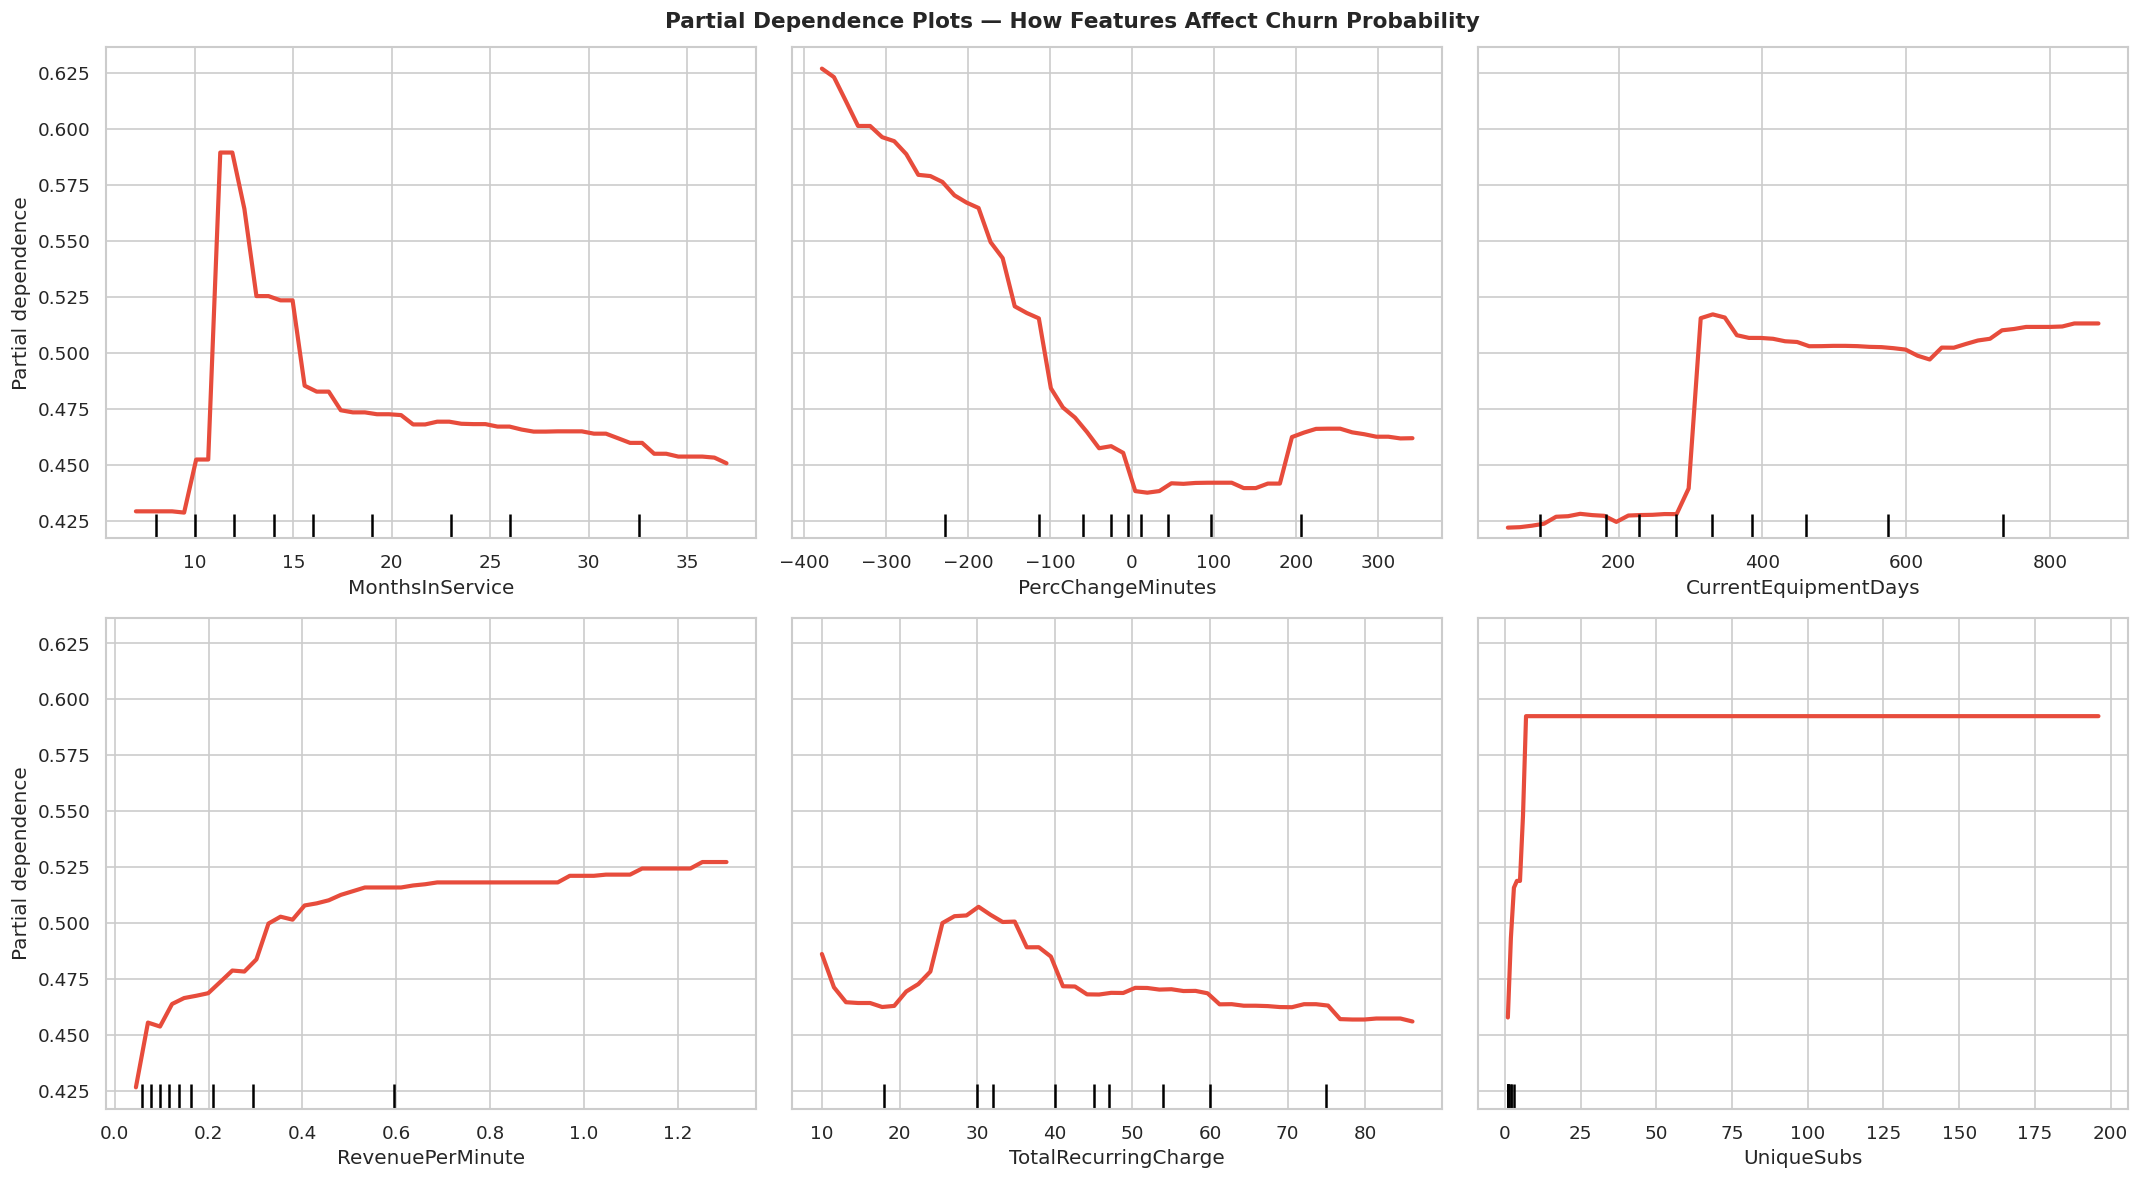

In [23]:
# ============================================================
# CELL 23: PARTIAL DEPENDENCE PLOTS
# ============================================================
from sklearn.inspection import PartialDependenceDisplay

# Top features from permutation importance
top_features_pdp = perm_df.head(6)['Feature'].tolist()

fig, ax = plt.subplots(2, 3, figsize=(18, 10))
PartialDependenceDisplay.from_estimator(
    results['XGBoost (Tuned)']['model'],
    X_test, top_features_pdp,
    ax=ax, grid_resolution=50,
    line_kw={'color': '#e74c3c', 'linewidth': 2.5}
)
plt.suptitle('Partial Dependence Plots — How Features Affect Churn Probability',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

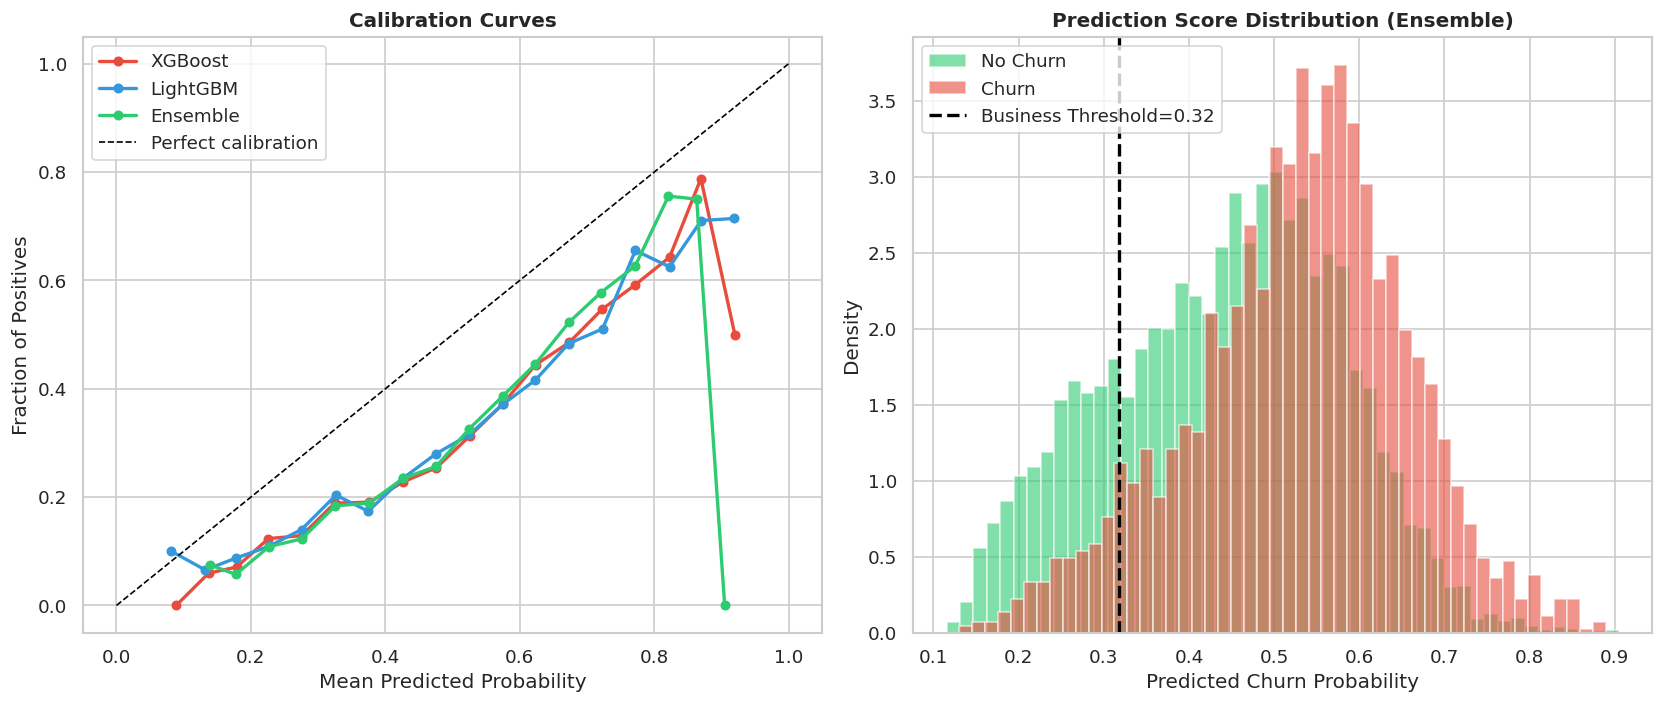

In [24]:
# ============================================================
# CELL 24: CHURN PROBABILITY CALIBRATION
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Calibration curves
for model_name, color in [('XGBoost (Tuned)', '#e74c3c'), ('LightGBM (Tuned)', '#3498db'), 
                            ('Ensemble (Weighted Avg)', '#2ecc71')]:
    r = results[model_name]
    fraction_pos, mean_pred = calibration_curve(y_test, r['prob_test'], n_bins=20)
    axes[0].plot(mean_pred, fraction_pos, 'o-', color=color, linewidth=2,
                 label=f"{model_name.split(' (')[0]}", markersize=5)
axes[0].plot([0,1],[0,1], 'k--', linewidth=1, label='Perfect calibration')
axes[0].set_xlabel('Mean Predicted Probability')
axes[0].set_ylabel('Fraction of Positives')
axes[0].set_title('Calibration Curves', fontweight='bold')
axes[0].legend()

# Score distribution
ens_probs = results['Ensemble (Weighted Avg)']['prob_test']
axes[1].hist(ens_probs[y_test == 0], bins=50, alpha=0.6, color='#2ecc71', density=True, label='No Churn')
axes[1].hist(ens_probs[y_test == 1], bins=50, alpha=0.6, color='#e74c3c', density=True, label='Churn')
axes[1].axvline(best_biz_thresh, color='black', linestyle='--', linewidth=2, label=f'Business Threshold={best_biz_thresh:.2f}')
axes[1].set_xlabel('Predicted Churn Probability')
axes[1].set_ylabel('Density')
axes[1].set_title('Prediction Score Distribution (Ensemble)', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.show()

## 10. 💼 Business Insights & Recommendations

In [25]:
# ============================================================
# CELL 25: CUSTOMER RISK SEGMENTATION
# ============================================================
# Apply best threshold from business analysis
test_df_results = df.iloc[X_test.index].copy() if hasattr(X_test, 'index') else df.sample(len(y_test), random_state=SEED).copy()
test_df_results = pd.DataFrame(X_test, columns=X.columns).copy()
test_df_results['actual_churn'] = y_test.values
test_df_results['churn_prob'] = results['Ensemble (Weighted Avg)']['prob_test']

# Risk segments
def segment(prob):
    if prob >= 0.7:   return '🔴 Very High Risk'
    elif prob >= 0.5: return '🟠 High Risk'
    elif prob >= 0.3: return '🟡 Medium Risk'
    else:             return '🟢 Low Risk'

test_df_results['risk_segment'] = test_df_results['churn_prob'].apply(segment)

segment_analysis = test_df_results.groupby('risk_segment').agg(
    count=('actual_churn', 'count'),
    actual_churn_rate=('actual_churn', 'mean'),
    avg_churn_prob=('churn_prob', 'mean')
).reset_index()
segment_analysis['pct_of_base'] = segment_analysis['count'] / segment_analysis['count'].sum()

print('🎯 Customer Risk Segmentation:')
display(segment_analysis.style
    .background_gradient(subset=['actual_churn_rate'], cmap='RdYlGn_r')
    .format({'actual_churn_rate': '{:.1%}', 'avg_churn_prob': '{:.1%}', 'pct_of_base': '{:.1%}'})
    .set_caption('Risk Segment Analysis on Test Set'))

# Visualization
fig = px.treemap(
    segment_analysis,
    path=['risk_segment'],
    values='count',
    color='actual_churn_rate',
    color_continuous_scale='RdYlGn_r',
    title='<b>Customer Risk Segmentation — Treemap</b>',
    hover_data=['actual_churn_rate', 'avg_churn_prob']
)
fig.update_layout(height=400, template='plotly_white')
fig.show()

🎯 Customer Risk Segmentation:


,risk_segment,count,actual_churn_rate,avg_churn_prob,pct_of_base
0,🔴 Very High Risk,339,61.9%,75.4%,3.3%
1,🟠 High Risk,4192,39.3%,57.8%,41.1%
2,🟡 Medium Risk,4186,22.2%,41.3%,41.0%
3,🟢 Low Risk,1493,10.4%,23.6%,14.6%


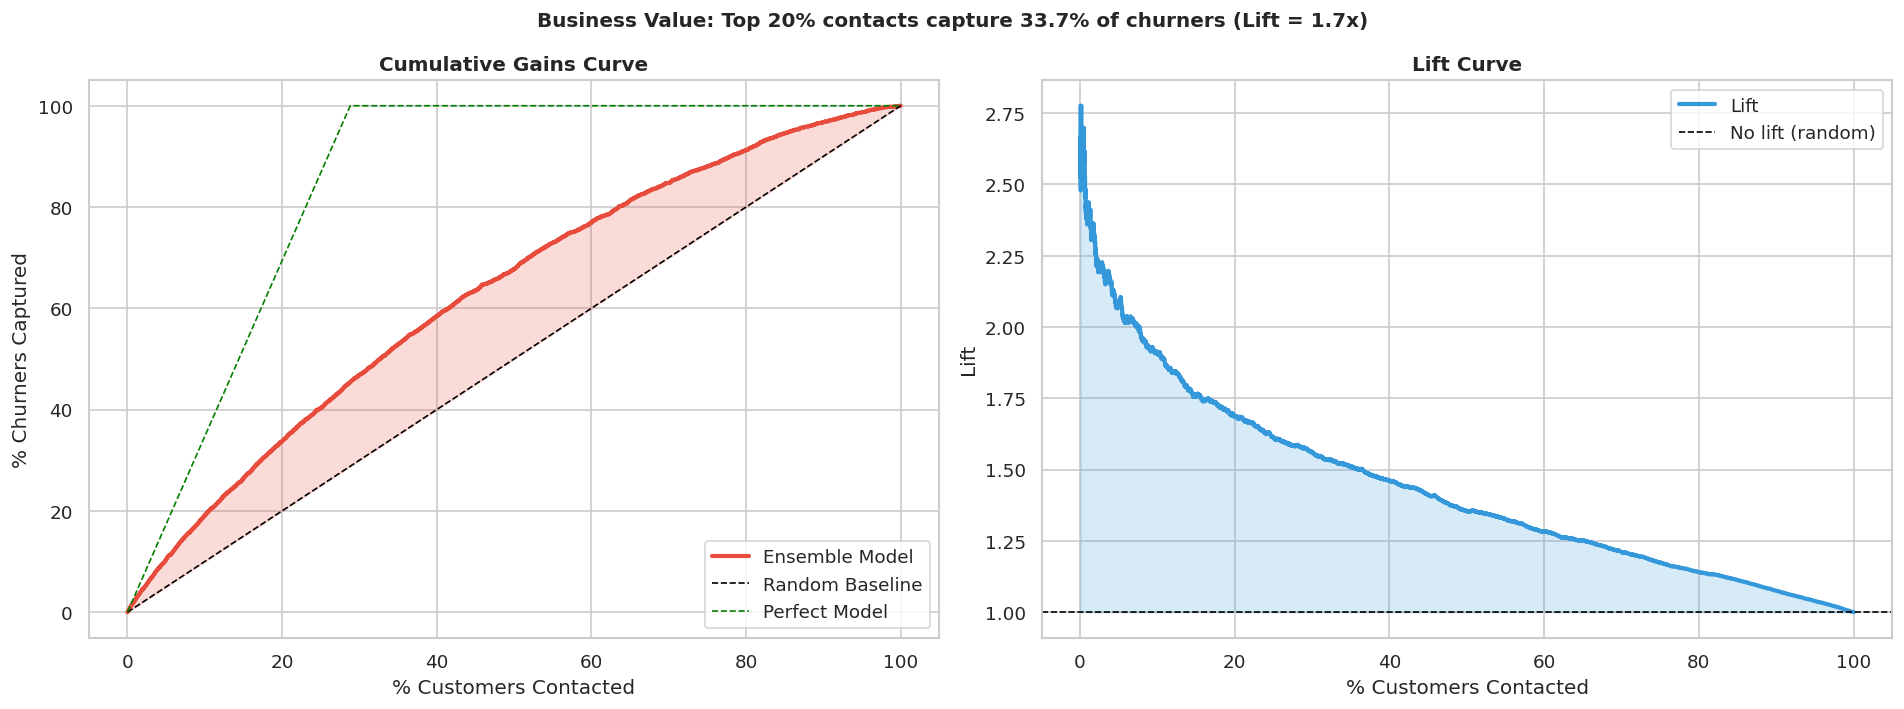


💡 Key Business Stats:
   Contacting top 20% → captures 33.7% of all churners (1.7x lift vs random)
   Contacting top 30% → captures 46.8% of all churners
   Contacting top 50% → captures 67.7% of all churners


In [26]:
# ============================================================
# CELL 26: BUSINESS VALUE — LIFT CURVE
# ============================================================
# Sort by predicted probability descending
sorted_idx = np.argsort(results['Ensemble (Weighted Avg)']['prob_test'])[::-1]
sorted_actual = y_test.values[sorted_idx]

n_test = len(y_test)
total_churners = y_test.sum()

pct_contacted = np.linspace(0, 100, n_test)
cumulative_churners_caught = np.cumsum(sorted_actual) / total_churners * 100
random_line = pct_contacted  # Random baseline

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gains curve
axes[0].plot(pct_contacted, cumulative_churners_caught, color='#e74c3c', linewidth=2.5, label='Ensemble Model')
axes[0].plot([0, 100], [0, 100], 'k--', linewidth=1, label='Random Baseline')
axes[0].plot([0, total_churners/n_test*100, 100], [0, 100, 100], 'g--', linewidth=1, label='Perfect Model')
axes[0].fill_between(pct_contacted, random_line, cumulative_churners_caught, alpha=0.2, color='#e74c3c')
axes[0].set_xlabel('% Customers Contacted')
axes[0].set_ylabel('% Churners Captured')
axes[0].set_title('Cumulative Gains Curve', fontweight='bold')
axes[0].legend()

# Lift curve
lift = (cumulative_churners_caught + 1e-10) / (pct_contacted + 1e-10)
axes[1].plot(pct_contacted[10:], lift[10:], color='#3498db', linewidth=2.5, label='Lift')
axes[1].axhline(1, color='k', linestyle='--', linewidth=1, label='No lift (random)')
axes[1].fill_between(pct_contacted[10:], 1, lift[10:], where=lift[10:] > 1, alpha=0.2, color='#3498db')
axes[1].set_xlabel('% Customers Contacted')
axes[1].set_ylabel('Lift')
axes[1].set_title('Lift Curve', fontweight='bold')
axes[1].legend()

# Key stats
top20_churn_pct = np.sum(sorted_actual[:int(0.2*n_test)]) / total_churners * 100
lift_top20 = top20_churn_pct / 20

plt.suptitle(f'Business Value: Top 20% contacts capture {top20_churn_pct:.1f}% of churners (Lift = {lift_top20:.1f}x)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('lift_curve.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\n💡 Key Business Stats:')
print(f'   Contacting top 20% → captures {top20_churn_pct:.1f}% of all churners ({lift_top20:.1f}x lift vs random)')
print(f'   Contacting top 30% → captures {np.sum(sorted_actual[:int(0.3*n_test)])/total_churners*100:.1f}% of all churners')
print(f'   Contacting top 50% → captures {np.sum(sorted_actual[:int(0.5*n_test)])/total_churners*100:.1f}% of all churners')

In [27]:
# ============================================================
# CELL 27: ROI ANALYSIS
# ============================================================
print('='*65)
print('         💰 BUSINESS ROI ANALYSIS')
print('='*65)

# Assumptions
avg_monthly_revenue = df['MonthlyRevenue'].median()
avg_clv = avg_monthly_revenue * 24  # 2-year CLV estimate
retention_cost = 50   # Cost of retention offer per customer
retention_success_rate = 0.35  # 35% of targeted churners retained

n_total_customers = len(df)
n_churners_total = (df['Churn'] == 'Yes').sum()

print(f'\n📊 Dataset Stats:')
print(f'   Total customers       : {n_total_customers:,}')
print(f'   Total churners        : {n_churners_total:,} ({n_churners_total/n_total_customers:.1%})')
print(f'   Avg Monthly Revenue   : ${avg_monthly_revenue:.2f}')
print(f'   Estimated 2-yr CLV    : ${avg_clv:.0f}')

print(f'\n🎯 Model-Driven Retention Campaign (Top 30%):')
n_targeted = int(0.3 * n_total_customers)
churners_in_top30_pct = np.sum(sorted_actual[:int(0.3*n_test)]) / len(y_test)
churners_targeted = int(churners_in_top30_pct * n_total_customers)
print(f'   Customers targeted    : {n_targeted:,}')
print(f'   Churners in target    : ~{churners_targeted:,}')
print(f'   Campaign cost         : ${n_targeted * retention_cost:,.0f}')
retained = int(churners_targeted * retention_success_rate)
revenue_saved = retained * avg_clv
roi = (revenue_saved - n_targeted * retention_cost) / (n_targeted * retention_cost) * 100
print(f'   Est. customers retained: {retained:,}')
print(f'   Revenue saved         : ${revenue_saved:,.0f}')
print(f'   Net ROI               : {roi:.0f}%')

print(f'\n📈 Without Model (Random targeting, same 30% budget):')
random_churners = int(0.3 * n_churners_total)
random_retained = int(random_churners * retention_success_rate)
random_revenue = random_retained * avg_clv
random_roi = (random_revenue - n_targeted * retention_cost) / (n_targeted * retention_cost) * 100
print(f'   Churners in target    : ~{random_churners:,}')
print(f'   Revenue saved         : ${random_revenue:,.0f}')
print(f'   Net ROI               : {random_roi:.0f}%')

print(f'\n🚀 Model Advantage:')
print(f'   Extra revenue saved   : ${revenue_saved - random_revenue:,.0f}')
print(f'   ROI improvement       : +{roi - random_roi:.0f} percentage points')
print('='*65)

         💰 BUSINESS ROI ANALYSIS

📊 Dataset Stats:
   Total customers       : 51,047
   Total churners        : 14,711 (28.8%)
   Avg Monthly Revenue   : $48.46
   Estimated 2-yr CLV    : $1163

🎯 Model-Driven Retention Campaign (Top 30%):
   Customers targeted    : 15,314
   Churners in target    : ~6,884
   Campaign cost         : $765,700
   Est. customers retained: 2,409
   Revenue saved         : $2,801,763
   Net ROI               : 266%

📈 Without Model (Random targeting, same 30% budget):
   Churners in target    : ~4,413
   Revenue saved         : $1,795,734
   Net ROI               : 135%

🚀 Model Advantage:
   Extra revenue saved   : $1,006,030
   ROI improvement       : +131 percentage points


In [28]:
# ============================================================
# CELL 28: KEY INSIGHTS
# ============================================================
print('='*70)
print('          🔑  KEY BUSINESS INSIGHTS')
print('='*70)

insights = [
    ("📞 Customer Care Calls",
     f"Customers making >2 care calls churn at {df[df['CustomerCareCalls']>2]['Churn'].eq('Yes').mean():.1%} "
     f"vs {df[df['CustomerCareCalls']<=2]['Churn'].eq('Yes').mean():.1%} overall — flag high-care users"),
    
    ("📱 Retention Calls",
     f"{df[(df['RetentionCalls']>0) & (df['RetentionOffersAccepted']==0)]['Churn'].eq('Yes').mean():.1%} "
     "churn rate for customers called but who refused offers — prioritize offer quality"),
    
    ("📉 Revenue Decline",
     f"Customers with >10% revenue decline: "
     f"{df[df['PercChangeRevenues'] < -10]['Churn'].eq('Yes').mean():.1%} churn rate — early warning signal"),
    
    ("💳 Credit Rating",
     f"Lowest credit (6-VeryLow, 7-Lowest) customers: "
     f"{df[df['CreditRating'].isin(['6-VeryLow','7-Lowest'])]['Churn'].eq('Yes').mean():.1%} churn — financial stress indicator"),
    
    ("🏠 Homeownership",
     f"Unknown homeownership: {df[df['Homeownership']=='Unknown']['Churn'].eq('Yes').mean():.1%} churn "
     f"vs Known: {df[df['Homeownership']=='Known']['Churn'].eq('Yes').mean():.1%} — incomplete data = churn signal"),
    
    ("📊 Tenure Segments",
     f"New customers (0-12 months): highest churn risk window — onboarding critical"),
    
    ("📡 Call Quality",
     f"High dropped/blocked calls strongly correlate with churn — network quality matters"),
]

for title, insight in insights:
    print(f'\n  {title}')
    print(f'    → {insight}')

print('\n' + '='*70)
print('          🎯  RECOMMENDED ACTIONS')
print('='*70)
actions = [
    '1. Deploy model weekly to score all customers → prioritize top 20% for retention',
    '2. Auto-flag customers with ≥3 care calls in 30 days for proactive outreach',
    '3. Create tailored retention offers for low credit-rating customers',
    '4. Improve network quality in high dropout areas (ServiceArea analysis)',
    '5. Design dedicated onboarding program for customers in first 12 months',
    '6. A/B test retention offer types for customers who previously refused',
    '7. Set up real-time scoring API for CRM integration',
]
for a in actions:
    print(f'  {a}')

          🔑  KEY BUSINESS INSIGHTS

  📞 Customer Care Calls
    → Customers making >2 care calls churn at 24.8% vs 29.9% overall — flag high-care users

  📱 Retention Calls
    → 49.1% churn rate for customers called but who refused offers — prioritize offer quality

  📉 Revenue Decline
    → Customers with >10% revenue decline: 30.3% churn rate — early warning signal

  💳 Credit Rating
    → Lowest credit (6-VeryLow, 7-Lowest) customers: 28.4% churn — financial stress indicator

  🏠 Homeownership
    → Unknown homeownership: 29.7% churn vs Known: 28.4% — incomplete data = churn signal

  📊 Tenure Segments
    → New customers (0-12 months): highest churn risk window — onboarding critical

  📡 Call Quality
    → High dropped/blocked calls strongly correlate with churn — network quality matters

          🎯  RECOMMENDED ACTIONS
  1. Deploy model weekly to score all customers → prioritize top 20% for retention
  2. Auto-flag customers with ≥3 care calls in 30 days for proactive outreach
 

## 11. 💾 Save Best Model

In [29]:
# ============================================================
# CELL 29: SAVE MODELS & ARTIFACTS
# ============================================================
import pickle

# Save tuned models
with open('xgb_tuned_model.pkl', 'wb') as f:
    pickle.dump(results['XGBoost (Tuned)']['model'], f)

with open('lgbm_tuned_model.pkl', 'wb') as f:
    pickle.dump(results['LightGBM (Tuned)']['model'], f)

with open('rf_model.pkl', 'wb') as f:
    pickle.dump(results['Random Forest']['model'], f)

with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

with open('encoders.pkl', 'wb') as f:
    pickle.dump(encoders, f)

# Save feature list
feature_list = list(X.columns)
with open('feature_list.json', 'w') as f:
    json.dump(feature_list, f)

# Save ensemble config
ensemble_config = {
    'models': ensemble_models,
    'weights': weights.tolist(),
    'optimal_threshold': float(best_biz_thresh),
    'best_f1_threshold': float(best_f1_thresh),
    'test_auc': float(ensemble_auc)
}
with open('ensemble_config.json', 'w') as f:
    json.dump(ensemble_config, f, indent=2)

print('✅ All artifacts saved:')
print('   📦 xgb_tuned_model.pkl')
print('   📦 lgbm_tuned_model.pkl')
print('   📦 rf_model.pkl')
print('   📦 scaler.pkl')
print('   📦 encoders.pkl')
print('   📋 feature_list.json')
print('   📋 ensemble_config.json')

✅ All artifacts saved:
   📦 xgb_tuned_model.pkl
   📦 lgbm_tuned_model.pkl
   📦 rf_model.pkl
   📦 scaler.pkl
   📦 encoders.pkl
   📋 feature_list.json
   📋 ensemble_config.json


In [30]:
# ============================================================
# CELL 30: FINAL SUMMARY DASHBOARD
# ============================================================
best = results['Ensemble (Weighted Avg)']

print('╔' + '═'*68 + '╗')
print('║' + '    🏆 FINAL MODEL PERFORMANCE SUMMARY'.center(68) + '║')
print('╠' + '═'*68 + '╣')
print(f'║  Dataset         : Cell2Cell Telecom ({len(df):,} customers)'.ljust(69) + '║')
print(f'║  Features Used   : {X.shape[1]} (including {len(new_features)} engineered)'.ljust(69) + '║')
print(f'║  Best Model      : Ensemble (XGBoost + LightGBM + RF)'.ljust(69) + '║')
print('╠' + '═'*68 + '╣')
print(f'║  Test ROC-AUC        : {best["test_auc"]:.4f}'.ljust(69) + '║')
print(f'║  Test F1 Score       : {best["f1"]:.4f}'.ljust(69) + '║')
print(f'║  Avg Precision (AP)  : {best["avg_precision"]:.4f}'.ljust(69) + '║')
print(f'║  Precision           : {best["precision"]:.4f}'.ljust(69) + '║')
print(f'║  Recall              : {best["recall"]:.4f}'.ljust(69) + '║')
print('╠' + '═'*68 + '╣')
print(f'║  Optimal Business Threshold : {best_biz_thresh:.2f}'.ljust(69) + '║')
print(f'║  Top 20% lift               : {lift_top20:.1f}x vs random targeting'.ljust(69) + '║')
print('╚' + '═'*68 + '╝')

print('\n📊 All Models Ranked by Test AUC:')
display(metrics_df[['Model', 'Test AUC', 'F1', 'Avg Precision']].style
    .background_gradient(subset=['Test AUC'], cmap='YlGn')
    .format(precision=4)
    .hide(axis='index'))

╔════════════════════════════════════════════════════════════════════╗
║                   🏆 FINAL MODEL PERFORMANCE SUMMARY                ║
╠════════════════════════════════════════════════════════════════════╣
║  Dataset         : Cell2Cell Telecom (51,047 customers)            ║
║  Features Used   : 78 (including 25 engineered)                    ║
║  Best Model      : Ensemble (XGBoost + LightGBM + RF)              ║
╠════════════════════════════════════════════════════════════════════╣
║  Test ROC-AUC        : 0.6799                                      ║
║  Test F1 Score       : 0.4967                                      ║
║  Avg Precision (AP)  : 0.4554                                      ║
║  Precision           : 0.4096                                      ║
║  Recall              : 0.6309                                      ║
╠════════════════════════════════════════════════════════════════════╣
║  Optimal Business Threshold : 0.32                                 ║
║  Top

Model,Test AUC,F1,Avg Precision
LightGBM (Tuned),0.6810,0.4945,0.4567
XGBoost (Tuned),0.6804,0.4991,0.4550
Ensemble (Weighted Avg),0.6799,0.4967,0.4554
XGBoost,0.6771,0.4914,0.4547
LightGBM,0.6706,0.4561,0.4439
Random Forest,0.6615,0.4780,0.4333
Logistic Regression,0.6263,0.4530,0.3958
